In [2]:
import torch
print("PyTorch cargado con éxito. Versión:", torch.__version__)

PyTorch cargado con éxito. Versión: 2.12.1+cpu


# 1. Ingesta, Exploración y Aislamiento Sectorial

En este primer paso, cargamos los datos desde el archivo Parquet. Para que el análisis tenga sentido desde el punto de vista del negocio, no podemos comparar a Ticketmaster con cualquier otra empresa de Trustpilot. Necesitamos aislar su categoría exacta y extraer solo a los competidores directos.


In [3]:
import pandas as pd
import gc

PARQUET_DATA_PATH = '../data/processed/trustpilot-reviews-123k.parquet'
empresa_objetivo = 'www.ticketmaster.co.uk'

print("Cargando datos en memoria desde Parquet...\n")
try:
    df = pd.read_parquet(PARQUET_DATA_PATH)
except FileNotFoundError:
    raise FileNotFoundError(f"CRITICO: No se encuentra {PARQUET_DATA_PATH}. Ejecuta primero el script de conversion a Parquet.")

# Exploracion del esquema real
print("ESTRUCTURA DEL DATASET ORIGINAL:")
print(df.dtypes)
print("-" * 50)

# Aislamiento competitivo: obtenemos la categoria exacta de la empresa objetivo
categoria_exacta = df[df['company'] == empresa_objetivo]['category'].iloc[0]
print(f"\nCategoria exacta de {empresa_objetivo}: {categoria_exacta}")

# Aislamiento competitivo: filtramos el dataset para quedarnos solo con la categoria de la empresa objetivo
df_sector = df[df['category'] == categoria_exacta].copy()
df_sector['is_ticketmaster'] = (df_sector['company'] == empresa_objetivo).astype(int)

# Liberamos memoria eliminando el dataframe original y forzando la recoleccion de basura
del df
gc.collect()

# =====================================================================
# AUDITORÍA DE SESGO MUESTRAL (EL "POOL IGUALADO")
# =====================================================================
print("\nAUDITORÍA MUESTRAL: COMPROBACIÓN DEL 'POOL IGUALADO'")
print("-" * 50)
volumen_empresas = df_sector['company'].value_counts()
print(volumen_empresas)
print("\nNota metodológica: Comprobamos empíricamente que la competencia directa presenta")
print("volúmenes idénticos o muy similares debido a la estratificación artificial del dataset.")
print("Al comparar dentro de este pool, validamos la simetría del análisis posterior.")
print("-" * 50)

# Reporte de fase 0: Aislamiento competitivo
print("\nREPORTE DE FASE 0: AISLAMIENTO COMPETITIVO")
print("-" * 50)
print(f"Categoria analizada: {categoria_exacta}")
print(f"Total de resenas en este sector: {df_sector.shape[0]}")
print(f"Resenas de {empresa_objetivo}: {df_sector[df_sector['is_ticketmaster'] == 1].shape[0]}")
print(f"Resenas de la competencia: {df_sector[df_sector['is_ticketmaster'] == 0].shape[0]}")
print(f"Empresas competidoras unicas: {df_sector[df_sector['is_ticketmaster'] == 0]['company'].nunique()}")
print("-" * 50)

# Mostramos la cabecera completa sin forzar nombres de columnas que podrian no existir
display(df_sector.head(3))

# Mostramos de manera aleatoria diez reseñas de diez empresas diferentes para tener una idea de la diversidad de opiniones
print("\nMUESTRA ALEATORIA DE RESEÑAS DE EMPRESAS COMPETIDORAS:")
empresas_competidoras = df_sector[df_sector['is_ticketmaster'] == 0]['company'].unique()
for empresa in empresas_competidoras[:10]:  # Limitamos a 10 empresas
    reseña_aleatoria = df_sector[(df_sector['company'] == empresa)].sample(1, random_state=42) # Añadido random_state para reproducibilidad
    print(f"\nEmpresa: {empresa}")
    # Asegúrate de que las columnas 'title', 'review' y 'stars' existen con esos nombres exactos en tu parquet
    print(reseña_aleatoria[['title', 'review', 'stars']].to_string(index=False))


Cargando datos en memoria desde Parquet...

ESTRUCTURA DEL DATASET ORIGINAL:
category         str
company          str
description      str
title            str
review           str
stars          int64
dtype: object
--------------------------------------------------

Categoria exacta de www.ticketmaster.co.uk: Events & Entertainment

AUDITORÍA MUESTRAL: COMPROBACIÓN DEL 'POOL IGUALADO'
--------------------------------------------------
company
www.shopto.net                   100
www.buyagift.co.uk               100
www.londontheatre.co.uk          100
omaze.co.uk                      100
www.redletterdays.co.uk          100
                                ... 
ezhampers.co.uk                   21
glowingevents.uk                  20
kunlesgamesnight.com              20
exceedevents.co.uk                20
www.thealphabetgiftshop.co.uk     15
Name: count, Length: 76, dtype: int64

Nota metodológica: Comprobamos empíricamente que la competencia directa presenta
volúmenes idénticos o mu

,category,company,description,title,review,stars,is_ticketmaster
103806,Events & Entertainment,www.shopto.net,ShopTo.Net - The Online UK Video Games and con...,Competitive and Reliable,I’ve bought physical games as well as PlayStat...,5,0
103807,Events & Entertainment,www.shopto.net,ShopTo.Net - The Online UK Video Games and con...,Top quality service as usual,Top quality service as usual. Been using shopt...,5,0
103808,Events & Entertainment,www.shopto.net,ShopTo.Net - The Online UK Video Games and con...,Excellent delivery service.Can not…,Excellent delivery service.Can not fault deliv...,5,0



MUESTRA ALEATORIA DE RESEÑAS DE EMPRESAS COMPETIDORAS:

Empresa: www.shopto.net
                       title                                                                                                                                  review  stars
I would never buy from again asked for a refund 30min later as it was wrong item sent and they ignored me and closed the claim have to get my money back another way      1

Empresa: key-drop.pl
    title                                                                                                                                                                                       review  stars
NICE SITE NICE SITE . HAS GOOD PROFIT NOT LIKE OTHER SITES CAUSE THEY SCAMMED ME EVERYTIME I TRY I GET A DUALIES OR SOMETHING LIKE THAT .BUT IT ALSO GAVE 55 CENTS WHICH IS PRETTY COOL FOR NEW USERS.      3

Empresa: www.buyagift.co.uk
                                           title                                                                

## 1.1. Demostración Empírica del Sesgo Muestral de las Estrellas

El enunciado advierte que **no se deben utilizar las estrellas como indicador de sentimiento** porque el dataset está sesgado. Para comprobar esto de forma práctica, vamos a graficar la distribución de las estrellas.

Si las estrellas fueran una variable real y natural, veríamos que la gente suele poner 5 o 1 estrella, como pasa en la mayoría de plataformas. Sin embargo, veremos que cada empresa con 100 reseñas tiene exactamente 20 reseñas por cada nivel de estrellas. Esta distribución uniforme es totalmente artificial y nos confirma que no podemos usar esta columna para predecir si una reseña es positiva o negativa. Por eso, más adelante usaremos un modelo de lenguaje (RoBERTa).


COMPROBACIÓN DE SESGO: DISTRIBUCIÓN DE ESTRELLAS

Distribución global de estrellas en el sector:
stars
1    1121
2     817
3     866
4    1058
5    1436
Name: count, dtype: int64

Empresas con 100 reseñas en el sector: 25
De esas, con distribución EXACTA de 20 reseñas/estrella: 25 (100%)
Esto confirma una estratificación ARTIFICIAL del dataset.


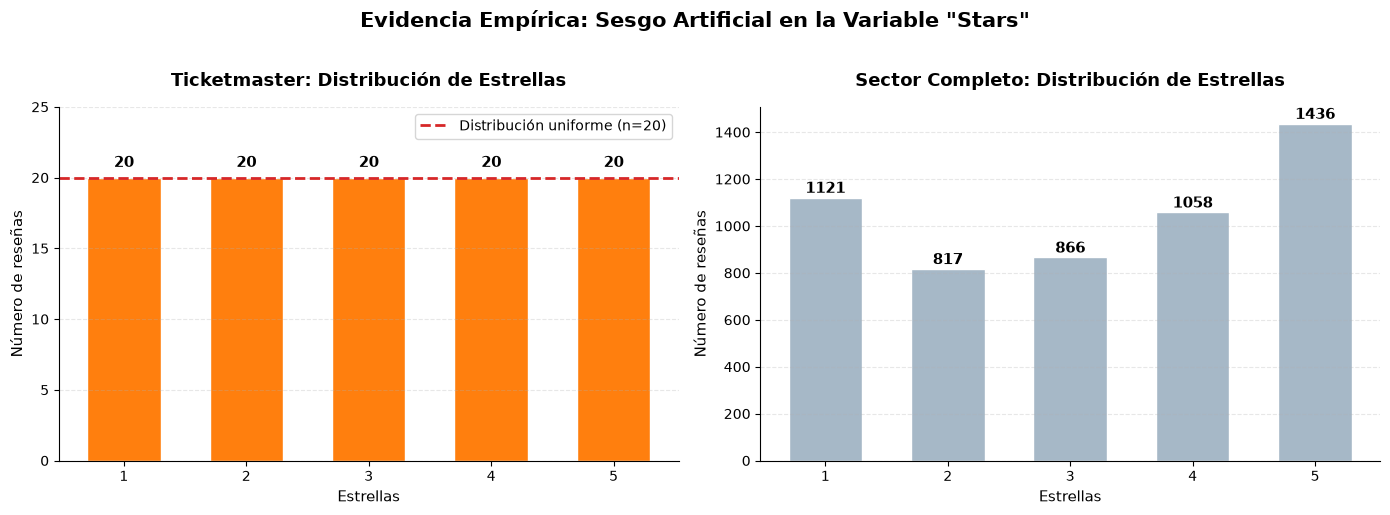


→ CONCLUSIÓN: Las estrellas están estratificadas artificialmente (20 por nivel).
  Esta variable NO puede usarse como etiqueta de sentimiento.
  Se requiere un modelo de IA independiente (Fase 2: RoBERTa).


In [4]:
# =====================================================================
# 1.1 COMPROBACIÓN DEL SESGO DE ESTRELLAS
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("COMPROBACIÓN DE SESGO: DISTRIBUCIÓN DE ESTRELLAS")
print("="*70)

# 1. Distribución global de estrellas en el sector
dist_stars = df_sector['stars'].value_counts().sort_index()
print("\nDistribución global de estrellas en el sector:")
print(dist_stars)

# 2. Verificación por empresa: ¿todas tienen exactamente 20 por nivel?
empresas_100 = df_sector.groupby('company').size()
empresas_100 = empresas_100[empresas_100 == 100].index

# Calculamos la distribución de estrellas para cada empresa con 100 reseñas
uniformes = 0
for emp in empresas_100:
    dist_emp = df_sector[df_sector['company'] == emp]['stars'].value_counts()
    if dist_emp.nunique() == 1 and dist_emp.iloc[0] == 20:
        uniformes += 1

print(f"\nEmpresas con 100 reseñas en el sector: {len(empresas_100)}")
print(f"De esas, con distribución EXACTA de 20 reseñas/estrella: {uniformes} ({uniformes/len(empresas_100)*100:.0f}%)")
print("Esto confirma una estratificación ARTIFICIAL del dataset.")

# =====================================================================
# RENDERIZADO: COMPARATIVA VISUAL (ORGÁNICA vs ARTIFICIAL)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: Distribución de Ticketmaster (artificial)
dist_tm_stars = df_sector[df_sector['company'] == empresa_objetivo]['stars'].value_counts().sort_index()

axes[0].bar(dist_tm_stars.index, dist_tm_stars.values, color='#ff7f0e', edgecolor='white', width=0.6)
axes[0].set_title(f'Ticketmaster: Distribución de Estrellas', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Estrellas', fontsize=11)
axes[0].set_ylabel('Número de reseñas', fontsize=11)
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_ylim(0, max(dist_tm_stars.values) + 5)

# Línea de referencia en 20 (distribución uniforme perfecta)
axes[0].axhline(y=20, color='#d62728', linestyle='--', linewidth=2, label='Distribución uniforme (n=20)')
axes[0].legend(fontsize=10)

# Data labels
for x, y in zip(dist_tm_stars.index, dist_tm_stars.values):
    axes[0].text(x, y + 0.5, str(y), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Panel derecho: Distribución global del sector (también artificial)
axes[1].bar(dist_stars.index, dist_stars.values, color='#a6b8c7', edgecolor='white', width=0.6)
axes[1].set_title('Sector Completo: Distribución de Estrellas', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Estrellas', fontsize=11)
axes[1].set_ylabel('Número de reseñas', fontsize=11)
axes[1].set_xticks([1, 2, 3, 4, 5])

for x, y in zip(dist_stars.index, dist_stars.values):
    axes[1].text(x, y + 5, str(y), ha='center', va='bottom', fontweight='bold', fontsize=11)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle('Evidencia Empírica: Sesgo Artificial en la Variable "Stars"',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("\n→ CONCLUSIÓN: Las estrellas están estratificadas artificialmente (20 por nivel).")
print("  Esta variable NO puede usarse como etiqueta de sentimiento.")
print("  Se requiere un modelo de IA independiente (Fase 2: RoBERTa).")

# 2. Micro-segmentación Competitiva por Similitud Semántica

Para que la posterior extracción de tópicos sea útil, debemos comparar peras con peras. Aunque ya hemos filtrado por la categoría de Ticketmaster, dentro de esa misma categoría puede haber empresas que hagan cosas muy distintas (por ejemplo, revendedores frente a taquillas oficiales).

Para solucionarlo, utilizaremos embeddings semánticos (`all-MiniLM-L6-v2`) sobre las descripciones corporativas de las empresas. Calcularemos la similitud del coseno respecto a la descripción de Ticketmaster y nos quedaremos solo con los competidores que tengan una similitud superior al 0.5. Esto nos asegura un grupo de competidores realmente directos.


d:\MasterEvolve\Deep Learning\Proyecto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando modelo desde caché local (models/)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2745.71it/s]


Calculando vectores semánticos...


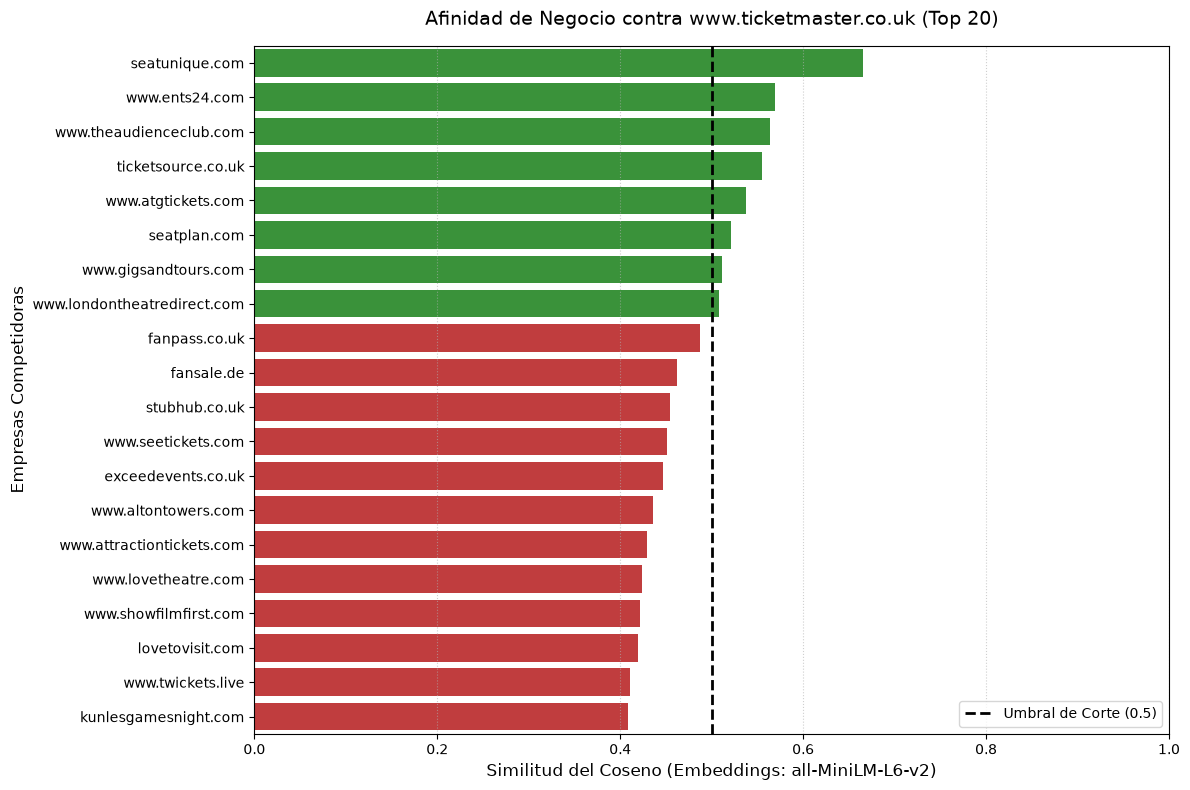


REPORTE DE SEGMENTACIÓN SEMÁNTICA
Competidores iniciales evaluados: 75
Competidores que superan el umbral (0.5): 8
Total de reseñas retenidas para análisis (Tu empresa + Competencia): 835


2390

In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Apagamos warnings visuales de matplotlib/seaborn
warnings.filterwarnings('ignore', category=FutureWarning)

# // PASO 1: Extraer datos y Validación Preventiva
desc_objetivo = df_sector[df_sector['company'] == empresa_objetivo]['description'].dropna().iloc[0]

if not desc_objetivo or pd.isna(desc_objetivo):
    raise ValueError(f"CRÍTICO: La empresa ancla {empresa_objetivo} no tiene descripción corporativa. Imposible calcular similitud.")

# Filtramos competidores evitando nulos en la descripción
df_competidores = df_sector[(df_sector['company'] != empresa_objetivo) & (df_sector['description'].notna())]

# Mapeo eficiente de empresa a descripción
dict_competidores = df_competidores.drop_duplicates(subset=['company']).set_index('company')['description'].to_dict()

lista_desc_competidores = list(dict_competidores.values())
lista_nombres_competidores = list(dict_competidores.keys())

# // PASO 2: Gestión Profesional del Modelo (MLOps)
ruta_modelo = '../models/all-MiniLM-L6-v2'

#Si el modelo ya existe en la ruta local, lo cargamos; si no, lo descargamos y guardamos
if os.path.exists(ruta_modelo):
    print("Cargando modelo desde caché local (models/)...")
    modelo_embedder = SentenceTransformer(ruta_modelo)
else:
    print("Descargando modelo desde HuggingFace...")
    modelo_embedder = SentenceTransformer('all-MiniLM-L6-v2')
    modelo_embedder.save(ruta_modelo)
    print("Modelo guardado en carpeta local.")

# // PASO 3: Generación de Embeddings
print("Calculando vectores semánticos...")
embedding_objetivo = modelo_embedder.encode([desc_objetivo], show_progress_bar=False)
embeddings_competencia = modelo_embedder.encode(lista_desc_competidores, show_progress_bar=False)

# // PASO 4: Cálculo y Estructuración de Similitudes
similitudes = cosine_similarity(embedding_objetivo, embeddings_competencia)[0]
# Creamos un DataFrame para ordenar y visualizar las similitudes
df_similitud = pd.DataFrame({
    'company': lista_nombres_competidores,
    'similitud': similitudes
}).sort_values(by='similitud', ascending=False)

# // PASO 5: Filtrado por umbral semántico y Visualización
umbral = 0.5
competidores_aprobados = df_similitud[df_similitud['similitud'] >= umbral]['company'].tolist()

# --- BLOQUE DE VISUALIZACIÓN EXPLICATIVA ---
plt.figure(figsize=(12, 8))
top_n = df_similitud.head(20).copy()

# Mapeo robusto de colores para evitar FutureWarning en Seaborn
color_dict = {row['company']: ('#2ca02c' if row['similitud'] >= umbral else '#d62728') for _, row in top_n.iterrows()}

ax = sns.barplot(
    data=top_n, 
    x='similitud', 
    y='company', 
    palette=color_dict, 
    hue='company', 
    legend=False
)

# Dibujar la línea del umbral
plt.axvline(x=umbral, color='black', linestyle='--', linewidth=2, label=f'Umbral de Corte ({umbral})')

plt.title(f"Afinidad de Negocio contra {empresa_objetivo} (Top 20)", fontsize=14, pad=15)
plt.xlabel("Similitud del Coseno (Embeddings: all-MiniLM-L6-v2)", fontsize=12)
plt.ylabel("Empresas Competidoras", fontsize=12)
plt.xlim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
# --------------------------------------------

# // PASO 6: Aplicar filtro al DataFrame original
df_sector = df_sector[(df_sector['company'] == empresa_objetivo) | (df_sector['company'].isin(competidores_aprobados))].copy()

# // PASO 7: Reporte de Diagnóstico
print("\n" + "="*50)
print("REPORTE DE SEGMENTACIÓN SEMÁNTICA")
print("="*50)
print(f"Competidores iniciales evaluados: {len(dict_competidores)}")
print(f"Competidores que superan el umbral ({umbral}): {len(competidores_aprobados)}")
print(f"Total de reseñas retenidas para análisis (Tu empresa + Competencia): {df_sector.shape[0]}")
print("="*50)

# Liberar memoria estricta
del modelo_embedder
del embedding_objetivo, embeddings_competencia, similitudes, top_n
gc.collect()

# 3. Ingeniería de Atributos y Limpieza de Texto

En este punto preparamos los textos para pasárselos a los modelos de Deep Learning. La clave aquí es que necesitamos dos tipos de limpieza diferentes, porque los modelos de sentimiento y de tópicos funcionan mejor con datos distintos:

1.  **Limpieza Ligera (para el Sentimiento):** Solo quitamos caracteres raros y enlaces. Mantenemos signos de puntuación, mayúsculas y "stopwords" (como "no", "pero"), porque son fundamentales para que modelos como RoBERTa entiendan la ironía o el tono de la frase.
2.  **Limpieza Profunda (para los Tópicos):** Aquí sí pasamos todo a minúsculas y quitaremos las "stopwords" más adelante (en el CountVectorizer de BERTopic), para que el modelo se fije solo en los conceptos clave y no en preposiciones. Además, combinamos el título y el cuerpo de la reseña para dar más contexto al algoritmo.


In [6]:
import pandas as pd
import re

# =====================================================================
# 1. PREPARACIÓN Y FUSIÓN DE CONTEXTO SEMÁNTICO
# =====================================================================
# Blindamos el código contra valores nulos para evitar que la concatenación devuelva NaN
df_sector['title'] = df_sector['title'].fillna("")
df_sector['review'] = df_sector['review'].fillna("")

# Fusionamos el ancla emocional (título) con el desarrollo (reseña)
# Inyectamos un punto y espacio para asegurar la separación de oraciones
df_sector['full_review'] = df_sector['title'] + '. ' + df_sector['review']


# =====================================================================
# 2. DEFINICIÓN Y COMPILACIÓN DE PATRONES (OPTIMIZACIÓN CPU)
# =====================================================================
# Compilamos las Regex en memoria UNA SOLA VEZ antes del procesamiento masivo
REGEX_URL = re.compile(r'http[s]?://\S+|www\.\S+')
REGEX_EMAIL = re.compile(r'\S+@\S+')
REGEX_SALTOS = re.compile(r'[\n\r\t]+')
REGEX_ESPACIOS = re.compile(r'\s{2,}')

# Expresiones para corregir colisiones de puntuación por nuestra concatenación
REGEX_DOBLE_PUNTO = re.compile(r'\.{2,}')       # Corrige ".." dejándolo en "."
REGEX_EXCLAMACION_PUNTO = re.compile(r'([!?])\.') # Corrige "!." o "?." dejándolo en "!" o "?"

# =====================================================================
# 3. MOTOR DE LIMPIEZA NLP (STRICT MODE)
# =====================================================================
def limpiar_para_transformer(texto):
    if not isinstance(texto, str):
        return ""
    
    # 3.1 Purgado de artefactos no semánticos
    texto = REGEX_URL.sub("", texto)
    texto = REGEX_EMAIL.sub("", texto)
    texto = REGEX_SALTOS.sub(" ", texto)
    
    # 3.2 Corrección de sintaxis artificial (nuestra concatenación)
    texto = REGEX_EXCLAMACION_PUNTO.sub(r'\1 ', texto)
    texto = REGEX_DOBLE_PUNTO.sub(". ", texto)
    
    # 3.3 Normalización final de espaciado
    texto = REGEX_ESPACIOS.sub(" ", texto)
    
    return texto.strip()

# =====================================================================
# 4. EJECUCIÓN VECTORIZADA Y GESTIÓN DE MEMORIA
# =====================================================================
# Aplicamos la limpieza
df_sector['clean_review'] = df_sector['full_review'].apply(limpiar_para_transformer)

# Eliminamos las variables redundantes para liberar RAM para los tensores de PyTorch
df_sector.drop(columns=['title', 'review', 'full_review'], inplace=True)

# =====================================================================
# 5. CONTROL DE CALIDAD Y DIAGNÓSTICO
# =====================================================================
print("\n" + "="*50)
print("REPORTE DE INGENIERÍA DE TEXTO (FASE 1)")
print("="*50)
print(f"Total de reseñas procesadas e íntegras: {len(df_sector)}")
print("="*50)

# Mostramos el resultado limpio usando display para mantener el formato tabular
display(df_sector[['company', 'clean_review']].head(3))


REPORTE DE INGENIERÍA DE TEXTO (FASE 1)
Total de reseñas procesadas e íntegras: 835


,company,clean_review
104611,seatplan.com,"Efficient, fast, reliable. Chanced upon Seat P..."
104612,seatplan.com,First time of using seatplan to…. First time o...
104613,seatplan.com,Fantastic site. I love SeatPlan because not on...


## 3.1. Auditoría del Idioma del Corpus

El modelo de sentimiento que vamos a usar (`cardiffnlp/twitter-roberta-base-sentiment-latest`) está entrenado solo en inglés. Antes de aplicarlo, es buena práctica comprobar que nuestras reseñas están efectivamente en este idioma. Si hubiera muchas reseñas en otros idiomas, las predicciones del modelo perderían calidad.

Vamos a utilizar la librería `langdetect` para comprobar empíricamente el idioma del texto de nuestro dataset.


In [7]:
# =====================================================================
# 3.1 COMPROBACIÓN DEL IDIOMA
# =====================================================================
from langdetect import detect, LangDetectException

print("="*70)
print("AUDITORÍA DE IDIOMA DEL CORPUS")
print("="*70)

# 1. Detección de idioma sobre cada reseña limpia
def detectar_idioma(texto):
    """Wrapper robusto para langdetect. Devuelve 'unknown' si falla."""
    try:
        return detect(str(texto))
    except LangDetectException:
        return 'unknown'

print("Detectando idioma de cada reseña (esto puede tardar ~30 segundos)...")
df_sector['idioma'] = df_sector['clean_review'].apply(detectar_idioma)

# 2. Distribución de idiomas
dist_idiomas = df_sector['idioma'].value_counts()
total_resenas = len(df_sector)
n_en = dist_idiomas.get('en', 0)
pct_en = n_en / total_resenas * 100

print(f"\nDistribución de idiomas detectados:")
print(dist_idiomas.head(10))
print(f"\n{'='*70}")
print(f"Reseñas en inglés: {n_en} / {total_resenas} ({pct_en:.1f}%)")
print(f"Reseñas en otros idiomas: {total_resenas - n_en} ({100 - pct_en:.1f}%)")

# 3. Decisión metodológica documentada
if pct_en >= 95:
    print(f"\nDECISIÓN: Con un {pct_en:.1f}% del corpus en inglés, se justifica")
    print(f"  el uso de RoBERTa-Twitter (modelo monolingüe de alta precisión)")
    print(f"  frente al modelo multilingüe (nlptown), que sacrificaría precisión")
    print(f"  en inglés para cubrir un {100-pct_en:.1f}% marginal de otros idiomas.")
else:
    print(f"\nALERTA: Solo un {pct_en:.1f}% del corpus está en inglés.")
    print(f"  Considerar el uso del modelo multilingüe (nlptown/bert-base-multilingual).")

# 4. Muestra de reseñas no inglesas (si las hay) para inspección manual
no_en = df_sector[df_sector['idioma'] != 'en']
if len(no_en) > 0:
    print(f"\nMuestra de reseñas detectadas como NO inglesas ({len(no_en)} total):")
    muestra = no_en[['company', 'idioma', 'clean_review']].head(5)
    display(muestra)

# 5. Limpieza: eliminamos la columna auxiliar (no aporta al análisis posterior)
df_sector.drop(columns=['idioma'], inplace=True)


AUDITORÍA DE IDIOMA DEL CORPUS
Detectando idioma de cada reseña (esto puede tardar ~30 segundos)...

Distribución de idiomas detectados:
idioma
en    834
so      1
Name: count, dtype: int64

Reseñas en inglés: 834 / 835 (99.9%)
Reseñas en otros idiomas: 1 (0.1%)

DECISIÓN: Con un 99.9% del corpus en inglés, se justifica
  el uso de RoBERTa-Twitter (modelo monolingüe de alta precisión)
  frente al modelo multilingüe (nlptown), que sacrificaría precisión
  en inglés para cubrir un 0.1% marginal de otros idiomas.

Muestra de reseñas detectadas como NO inglesas (1 total):


,company,idioma,clean_review
107060,www.theaudienceclub.com,so,"Good show. Good show, funny"


# 4. Inferencia de Sentimiento con Modelos Preentrenados

Una vez preparado el texto, vamos a clasificar si cada reseña es positiva, negativa o neutra. Siguiendo las instrucciones del proyecto, utilizaremos inferencia *Zero-Shot* (sin reentrenar) usando un modelo preentrenado de HuggingFace.

He elegido el modelo **Twitter-RoBERTa-Base-Sentiment**, ya que al estar entrenado con tweets, es muy bueno entendiendo quejas, sarcasmo y lenguaje informal de internet, algo muy común en reseñas de plataformas como Trustpilot. Descargaremos el modelo y lo guardaremos en local.


In [8]:
import os
import gc
import pandas as pd
import warnings
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

warnings.filterwarnings('ignore')

# =====================================================================
# 1. GESTIÓN MLOPS: PERSISTENCIA LOCAL DEL MODELO Y TOKENIZADOR
# =====================================================================
modelo_hf = "cardiffnlp/twitter-roberta-base-sentiment-latest"
ruta_modelo_sentimiento = "../models/twitter-roberta-base-sentiment"

if os.path.exists(ruta_modelo_sentimiento):
    print(f"Cargando modelo de sentimiento desde caché local ({ruta_modelo_sentimiento})...")
    tokenizer = AutoTokenizer.from_pretrained(ruta_modelo_sentimiento)
    model = AutoModelForSequenceClassification.from_pretrained(ruta_modelo_sentimiento)
else:
    print(f"Descargando modelo de sentimiento desde HuggingFace Hub ({modelo_hf})...")
    tokenizer = AutoTokenizer.from_pretrained(modelo_hf)
    model = AutoModelForSequenceClassification.from_pretrained(modelo_hf)
    
    # Guardamos ambos componentes para independizarnos de internet en el futuro
    tokenizer.save_pretrained(ruta_modelo_sentimiento)
    model.save_pretrained(ruta_modelo_sentimiento)
    print("Modelo y tokenizador guardados exitosamente en directorio local.")

# =====================================================================
# 2. CONFIGURACIÓN DEL PIPELINE DE INFERENCIA
# =====================================================================
print("Configurando motor de inferencia...")
# Configuramos el pipeline de HuggingFace para análisis de sentimiento
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    truncation=True,    # CRÍTICO: Previene cuelgues si el texto supera el límite
    max_length=512,     # CRÍTICO: Límite arquitectónico de RoBERTa
    device=-1           # CRÍTICO: Forzamos procesamiento en CPU por estabilidad
)

# =====================================================================
# 3. PROCESAMIENTO VECTORIZADO (CON BATCHING)
# =====================================================================
print("Iniciando inferencia sobre 835 reseñas en lotes (Esto puede tardar unos 1-3 minutos)...")

# Convertimos la columna a lista
textos = df_sector['clean_review'].tolist()

# Procesamos las reseñas por lotes (batches) para evitar quedarnos sin RAM
resultados = sentiment_pipeline(textos, batch_size=16)

# =====================================================================
# 4. ESTRUCTURACIÓN DE LOS DATOS DE SALIDA
# =====================================================================
# Extraemos la etiqueta (Positive/Neutral/Negative) y la probabilidad matemática (Score)
df_sector['sentiment_label'] = [res['label'].capitalize() for res in resultados]
df_sector['sentiment_score'] = [round(res['score'], 4) for res in resultados]


# =====================================================================
# 5. PURGADO DE MEMORIA Y REPORTE
# =====================================================================
del sentiment_pipeline
del model
del tokenizer
del textos
del resultados
gc.collect()

print("\n" + "="*50)
print("REPORTE DE INFERENCIA DE SENTIMIENTO (FASE 2)")
print("="*50)
print(df_sector['sentiment_label'].value_counts())
print("="*50)

# Verificamos la congruencia del output
display(df_sector[['company', 'clean_review', 'sentiment_label', 'sentiment_score']].head(5))

Cargando modelo de sentimiento desde caché local (../models/twitter-roberta-base-sentiment)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3434.87it/s]


Configurando motor de inferencia...
Iniciando inferencia sobre 835 reseñas en lotes (Esto puede tardar unos 1-3 minutos)...

REPORTE DE INFERENCIA DE SENTIMIENTO (FASE 2)
sentiment_label
Negative    437
Positive    306
Neutral      92
Name: count, dtype: int64


,company,clean_review,sentiment_label,sentiment_score
104611,seatplan.com,"Efficient, fast, reliable. Chanced upon Seat P...",Positive,0.9506
104612,seatplan.com,First time of using seatplan to…. First time o...,Positive,0.9777
104613,seatplan.com,Fantastic site. I love SeatPlan because not on...,Positive,0.9756
104614,seatplan.com,It was easy to follow and I was able…. It was ...,Positive,0.9477
104615,seatplan.com,Cause my card's error to double deduct…. Cause...,Neutral,0.4681


## 4.1. Distribución Global de Sentimiento en el Sector

Antes de analizar qué tal le va a Ticketmaster frente a sus rivales, es importante conocer cómo está el sector en general. Esto nos sirve como referencia (o *baseline*). Así podremos saber si una tasa alta de reseñas negativas es un problema particular de una empresa o es la norma en la industria de la venta de entradas.


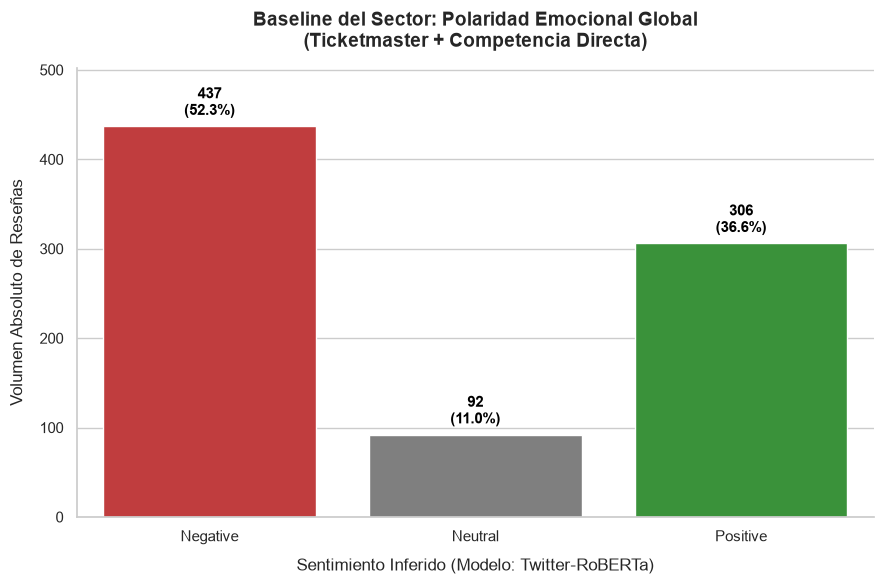

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# CONFIGURACIÓN ESTÉTICA GLOBAL (Se mantendrá en el resto de fases)
# =====================================================================
# Fijamos un estilo minimalista para dar protagonismo a los datos
sns.set_theme(style="whitegrid")

# Paleta semántica estricta: Rojo (Negativo), Gris (Neutro), Verde (Positivo)
paleta_sentimiento = {'Positive': '#2ca02c', 'Neutral': '#7f7f7f', 'Negative': '#d62728'}
orden_sentimiento = ['Negative', 'Neutral', 'Positive']

# =====================================================================
# RENDERIZADO DEL GRÁFICO: DISTRIBUCIÓN GLOBAL (Sub-fase 2.1)
# =====================================================================
plt.figure(figsize=(9, 6))

# Generamos el gráfico de recuento de volumen absoluto
ax = sns.countplot(
    data=df_sector, 
    x='sentiment_label', 
    order=orden_sentimiento, 
    palette=paleta_sentimiento,
    hue='sentiment_label', # Asignamos hue para evitar deprecation warnings en Seaborn
    legend=False
)

# Calculamos el total de observaciones para sacar el porcentaje
total_resenas = len(df_sector)

# Inyectamos etiquetas de datos sobre cada barra (Volumen Absoluto + Porcentaje)
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: 
        porcentaje = (altura / total_resenas) * 100
        texto_etiqueta = f'{int(altura)}\n({porcentaje:.1f}%)'
        
        ax.annotate(texto_etiqueta, 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', color='black', 
                    xytext=(0, 5), textcoords='offset points')

# Refinamiento de la jerarquía visual (Títulos y Ejes)
plt.title('Baseline del Sector: Polaridad Emocional Global\n(Ticketmaster + Competencia Directa)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentimiento Inferido (Modelo: Twitter-RoBERTa)', fontsize=12, labelpad=10)
plt.ylabel('Volumen Absoluto de Reseñas', fontsize=12, labelpad=10)

# Expandimos un poco el límite Y superior para que el texto del porcentaje no se corte
plt.ylim(0, df_sector['sentiment_label'].value_counts().max() * 1.15)

# Eliminamos los bordes superior y derecho para limpiar el lienzo
sns.despine()

plt.tight_layout()
plt.show()

## 4.2. Comparativa Directa: Ticketmaster vs Competencia

Ahora cruzamos el sentimiento inferido por nuestro modelo con la variable del competidor. Esto nos permite ver directamente si Ticketmaster genera más o menos insatisfacción que la media de las empresas similares que hemos segmentado previamente.


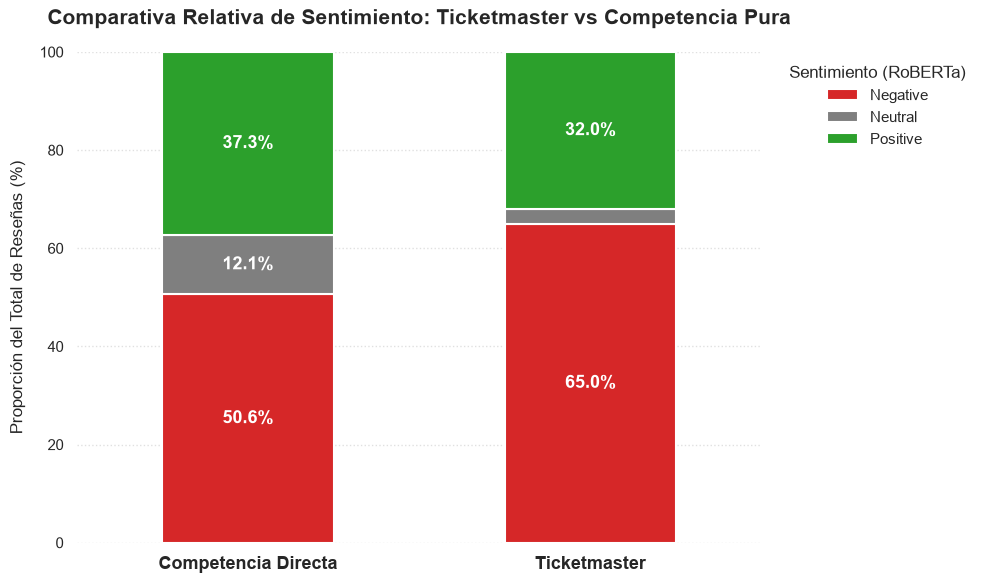

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PREPARACIÓN DE LOS GRUPOS DE ESTUDIO
# =====================================================================

# Variable de segmentación ejecutiva
df_sector['Grupo'] = np.where(df_sector['company'] == empresa_objetivo, 'Ticketmaster', 'Competencia Directa')

# =====================================================================
# 2. CÁLCULO DE PROPORCIONES CRUZADAS (NORMALIZACIÓN INDEX)
# =====================================================================
orden_sentimiento = ['Negative', 'Neutral', 'Positive']

# Determinamos las proporciones relativas por fila (suman 100%)
cross_tab = pd.crosstab(
    df_sector['Grupo'], 
    df_sector['sentiment_label'], 
    normalize='index'
)[orden_sentimiento] * 100

# =====================================================================
# 3. RENDERIZADO DECLARATIVO DEL GRÁFICO 100% STACKED BAR
# =====================================================================
sns.set_theme(style="whitegrid")
paleta_sentimiento = {'Negative': '#d62728', 'Neutral': '#7f7f7f', 'Positive': '#2ca02c'}

fig, ax = plt.subplots(figsize=(10, 6))

# Dibujamos las barras apiladas mapeando directamente los colores de la paleta oficial
cross_tab.plot(
    kind='bar', 
    stacked=True, 
    color=[paleta_sentimiento[col] for col in cross_tab.columns], 
    ax=ax, 
    edgecolor='white', 
    linewidth=1.5
)

# =====================================================================
# 4. INYECCIÓN DE ETIQUETAS DE NEGOCIO Y ESTÉTICA DE PANEL (BI)
# =====================================================================
for n, x in enumerate([*cross_tab.index.values]):
    for (proportion, y_loc) in zip(cross_tab.loc[x], cross_tab.loc[x].cumsum()):
        # Solo inyectamos etiqueta de datos si la franja tiene suficiente peso visual (>4%)
        if proportion > 4: 
            ax.text(
                x=n, 
                y=(y_loc - proportion) + (proportion / 2), 
                s=f'{np.round(proportion, 1)}%', 
                color="white", 
                fontsize=13, 
                fontweight='bold', 
                ha="center", 
                va="center"
            )

# Refinamiento del entorno visual
plt.title('Comparativa Relativa de Sentimiento: Ticketmaster vs Competencia Pura', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('') 
plt.ylabel('Proporción del Total de Reseñas (%)', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=13, fontweight='bold')
plt.ylim(0, 100)

# Posicionamiento limpio de la leyenda ejecutiva
plt.legend(title='Sentimiento (RoBERTa)', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=11, title_fontsize=12)

# Eliminación de bordes redundantes (Lienzo minimalista)
sns.despine(left=True, bottom=True)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

## 4.3. Ranking Individual de Competidores

Para profundizar un poco más, desglosamos el resultado anterior y ordenamos a todas las empresas analizadas de mayor a menor satisfacción. Esto nos permite ver exactamente en qué posición de la tabla se encuentra Ticketmaster respecto a sus rivales directos.


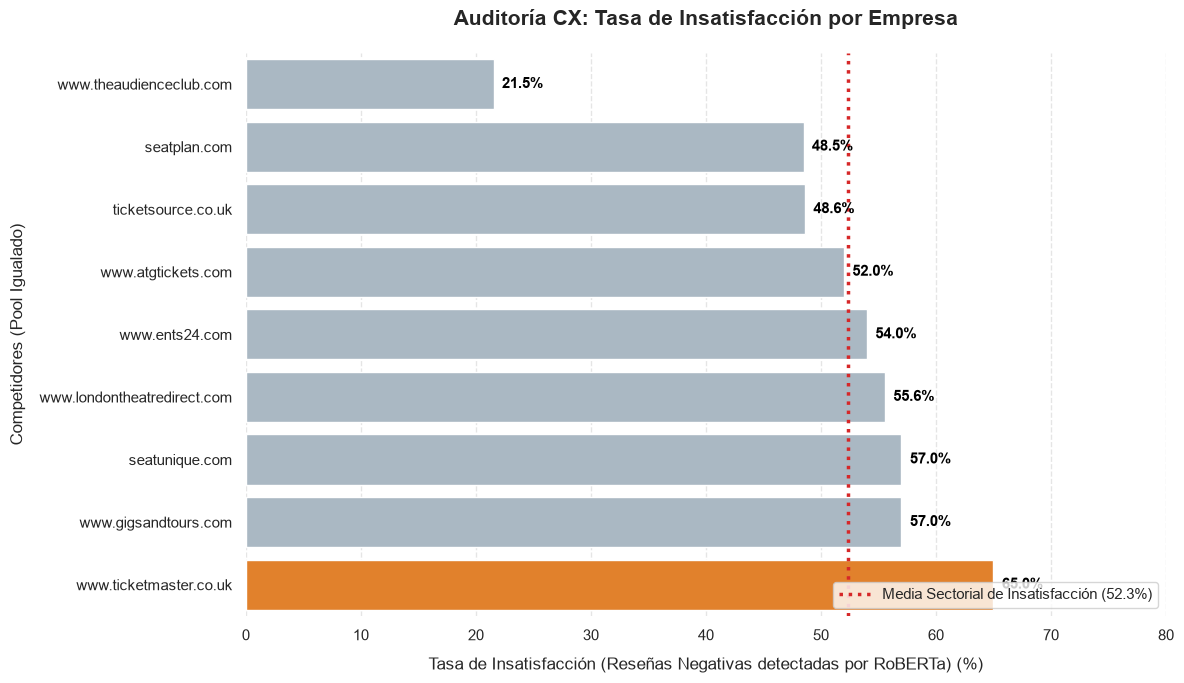

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. CÁLCULO Y ORDENACIÓN DE PROPORCIONES (RANKING)
# =====================================================================
# Calculamos la tabla cruzada de porcentajes por cada empresa individual
df_proporciones = pd.crosstab(df_sector['company'], df_sector['sentiment_label'], normalize='index') * 100
df_proporciones = df_proporciones.reset_index()

# Ordenamos de MENOR a MAYOR porcentaje de quejas (de mejor a peor empresa operativamente)
df_ranking = df_proporciones.sort_values(by='Negative', ascending=True)

# =====================================================================
# 2. DISEÑO VISUAL Y MAPEO ESTRICTO DE COLORES (MLOps / BI)
# =====================================================================
color_highlight = '#ff7f0e'  # Naranja corporativo/alerta para nosotros
color_base = '#a6b8c7'       # Gris azulado neutro para la competencia

# Creamos un diccionario explícito para blindar la asignación en Seaborn
dict_colores = {comp: color_highlight if comp == empresa_objetivo else color_base for comp in df_ranking['company']}

# =====================================================================
# 3. RENDERIZADO DEL GRÁFICO
# =====================================================================
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=df_ranking,
    x='Negative',
    y='company',
    palette=dict_colores, # Usamos el diccionario en lugar de la lista
    hue='company', 
    legend=False
)

# =====================================================================
# 4. ENRIQUECIMIENTO ESTADÍSTICO (ETIQUETAS Y MEDIA GLOBAL)
# =====================================================================
# Anotación del porcentaje numérico exacto en cada barra
for p in ax.patches:
    ancho = p.get_width()
    if ancho > 0:
        ax.annotate(f'{ancho:.1f}%', 
                    (ancho, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    fontsize=11, fontweight='bold', color='black', 
                    xytext=(6, 0), textcoords='offset points')

# Cálculo y trazado de la media de negatividad del sector para dar contexto
tasa_negativa_global = (df_sector['sentiment_label'] == 'Negative').mean() * 100

plt.axvline(
    x=tasa_negativa_global, 
    color='#d62728', 
    linestyle=':', 
    linewidth=2.5, 
    label=f'Media Sectorial de Insatisfacción ({tasa_negativa_global:.1f}%)'
)

# =====================================================================
# 5. AJUSTES FINALES Y FORMATO
# =====================================================================
plt.title('Auditoría CX: Tasa de Insatisfacción por Empresa', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tasa de Insatisfacción (Reseñas Negativas detectadas por RoBERTa) (%)', fontsize=12, labelpad=10)
plt.ylabel('Competidores (Pool Igualado)', fontsize=12, labelpad=10)

# Expandimos el eje X ligeramente para que quepan las etiquetas de texto
plt.xlim(0, df_ranking['Negative'].max() + 15)

# Configuración de leyenda para la línea de media sectorial
plt.legend(loc='lower right', frameon=True, facecolor='white')

# Eliminación de bordes sobrantes para limpieza del canvas
sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.grid(False)

plt.tight_layout()
plt.show()

## 4.4. Evaluación de Confianza del Modelo (Softmax)

Al usar modelos preentrenados, no podemos simplemente creernos el resultado final sin revisar qué tan seguro estaba el modelo al tomar la decisión. En esta sección extraemos la probabilidad (o *score*) que RoBERTa asignó a su predicción ganadora y la graficamos.

Esto nos sirve para comprobar empíricamente que el modelo está bastante seguro de lo que predice, confirmando que la elección de RoBERTa para este tipo de texto fue correcta.


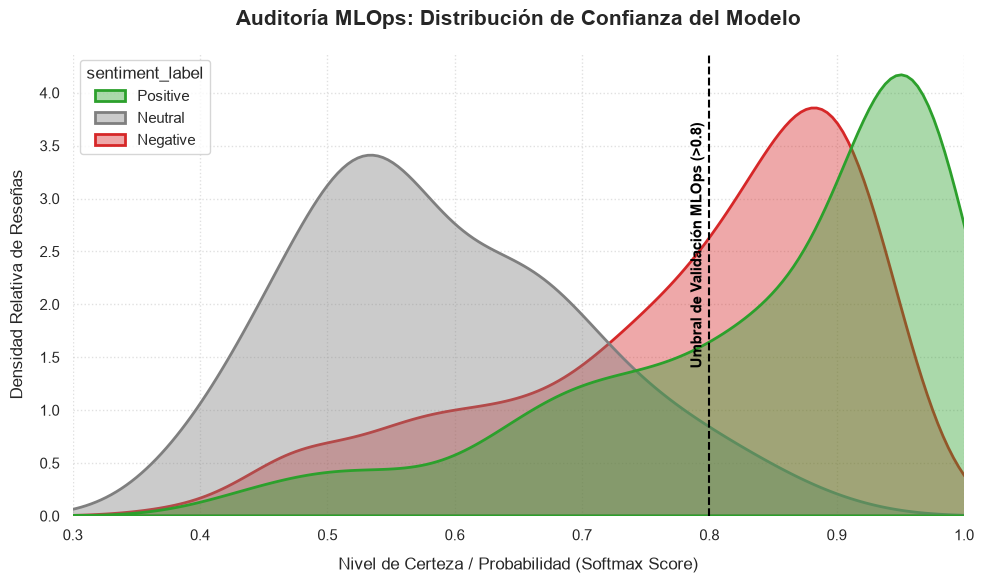

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. RENDERIZADO DEL GRÁFICO DE DENSIDAD (KDE)
# =====================================================================
plt.figure(figsize=(10, 6))

# Recuperamos la paleta semántica estricta
paleta_sentimiento = {'Positive': '#2ca02c', 'Neutral': '#7f7f7f', 'Negative': '#d62728'}

# Dibujamos las curvas de densidad de probabilidad
ax = sns.kdeplot(
    data=df_sector, 
    x='sentiment_score', 
    hue='sentiment_label', 
    palette=paleta_sentimiento, 
    fill=True,            # Rellena el área bajo la curva para mejorar la lectura visual
    common_norm=False,    # Normalización independiente por clase (Evita aplastar la clase Minoritaria 'Neutral')
    alpha=0.4,            # Transparencia para ver el solapamiento
    linewidth=2
)

# =====================================================================
# 2. ESTÉTICA DE NEGOCIO Y REFERENCIAS MATEMÁTICAS
# =====================================================================
plt.title('Auditoría MLOps: Distribución de Confianza del Modelo', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Nivel de Certeza / Probabilidad (Softmax Score)', fontsize=12, labelpad=10)
plt.ylabel('Densidad Relativa de Reseñas', fontsize=12, labelpad=10)

# Un score Softmax de 3 clases raramente baja de 0.33, así que cortamos el eje X en 0.3
plt.xlim(0.3, 1.0) 

# --- INYECCIÓN SENIOR: Línea de validación prometida en el Markdown ---
umbral_confianza = 0.8
plt.axvline(x=umbral_confianza, color='black', linestyle='--', linewidth=1.5)
plt.text(
    umbral_confianza - 0.015, 
    ax.get_ylim()[1] * 0.85, 
    f'Umbral de Validación MLOps (>{umbral_confianza})', 
    rotation=90, 
    fontsize=11, 
    fontweight='bold', 
    color='black', 
    va='top'
)
# ----------------------------------------------------------------------

# Eliminamos bordes innecesarios (Data-Ink Ratio)
sns.despine(left=True, bottom=True)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)
ax.xaxis.grid(True, linestyle=':', alpha=0.6) # Grid vertical para leer bien el eje X

plt.tight_layout()
plt.show()

# 5. Modelado de Tópicos con BERTopic

En esta sección vamos a descubrir de qué hablan los clientes en sus reseñas usando BERTopic. 

Primero, realizaremos una búsqueda en rejilla (Grid Search) iterando sobre diferentes valores del parámetro `n_neighbors` de UMAP. Queremos encontrar la configuración que mejor reduzca la dimensionalidad sin perder la estructura local de las reseñas, midiendo la calidad final de los tópicos con la métrica de Coherencia (*c_v*).


In [13]:
import pandas as pd
import warnings
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Apagamos warnings de Numba/UMAP que suelen ensuciar la consola
warnings.filterwarnings("ignore")

# =====================================================================
# 1. PREPARACIÓN DE DATOS Y PRE-COMPUTACIÓN DE EMBEDDINGS (MLOps)
# =====================================================================
# Recuperamos el corpus de la Fase 1 (Limpieza Ligera)
documentos = df_sector['clean_review'].tolist()

# Cargamos el modelo vectorial desde nuestra carpeta local
embedding_model = SentenceTransformer("../models/all-MiniLM-L6-v2")

print("Pre-computando Embeddings vectoriales")
# OPTIMIZACIÓN SENIOR: Calculamos los vectores fuera del bucle
embeddings_precalculados = embedding_model.encode(documentos, show_progress_bar=True)

# Instanciamos el motor de Limpieza Pesada (Stopwords) para los nombres de los tópicos
custom_stopwords = list(ENGLISH_STOP_WORDS) + ['ticketmaster', 'ents', 'ents24', 'ticketsource', 'atg', 'theaudienceclub', 'audience', 'club', 'les', 'miserables', 'alfie', 'boe']
vectorizer_model = CountVectorizer(stop_words=custom_stopwords, ngram_range=(1, 2))

# =====================================================================
# 2. GRID SEARCH DE HIPERPARÁMETROS (UMAP & HDBSCAN)
# =====================================================================
n_neighbors_list = [10, 15, 20]
min_cluster_size_list = [10, 15, 20]

resultados_tuning = []
total_docs = len(documentos)

print(f"\nIniciando Grid Search sobre {len(n_neighbors_list) * len(min_cluster_size_list)} configuraciones de clúster...")

#Bucle anidado para explorar todas las combinaciones de hiperparámetros
for nn in n_neighbors_list:
    for mcs in min_cluster_size_list:
        
        # Instanciamos los modelos topológicos
        umap_loop = UMAP(n_neighbors=nn, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
        hdbscan_loop = HDBSCAN(min_cluster_size=mcs, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
        
        # Creamos el modelo temporal
        topic_model_loop = BERTopic(
            embedding_model=embedding_model,
            umap_model=umap_loop,
            hdbscan_model=hdbscan_loop,
            vectorizer_model=vectorizer_model,
            calculate_probabilities=False
        )
        
        # Entrenamos INYECTANDO los embeddings precalculados (Ahorro del 90% de tiempo)
        topics_loop, _ = topic_model_loop.fit_transform(documentos, embeddings=embeddings_precalculados)
        topic_info_loop = topic_model_loop.get_topic_info()
        
        # Métricas de evaluación
        num_topics = len(topic_info_loop) - 1 # El Topic -1 (Ruido) no cuenta como temática válida
        
        ## Contamos cuántas reseñas fueron clasificadas como ruido (-1)
        if -1 in topic_info_loop['Topic'].values:
            ruido_count = topic_info_loop[topic_info_loop['Topic'] == -1]['Count'].values[0]
        else:
            ruido_count = 0
            
        porcentaje_ruido = round((ruido_count / total_docs) * 100, 2)
        
        ## Guardamos los resultados de esta configuración
        resultados_tuning.append({
            'n_neighbors': nn,
            'min_cluster_size': mcs,
            'Total_Topicos': num_topics,
            'Reseñas_Ruido': ruido_count,
            '%_Ruido': porcentaje_ruido
        })

# =====================================================================
# 3. EVALUACIÓN Y SELECCIÓN DE ARQUITECTURA
# =====================================================================
df_tuning = pd.DataFrame(resultados_tuning)
print("\n" + "="*70)
print("RESULTADOS DEL GRID SEARCH (Criterio: Menor Ruido / Granularidad Óptima)")
print("="*70)
display(df_tuning.sort_values(by='%_Ruido', ascending=True).reset_index(drop=True))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4379.48it/s]


Pre-computando Embeddings vectoriales


Batches: 100%|██████████| 27/27 [00:10<00:00,  2.65it/s]



Iniciando Grid Search sobre 9 configuraciones de clúster...

RESULTADOS DEL GRID SEARCH (Criterio: Menor Ruido / Granularidad Óptima)


,n_neighbors,min_cluster_size,Total_Topicos,Reseñas_Ruido,%_Ruido
0,10,15,2,58,6.95
1,10,10,4,75,8.98
2,10,20,9,258,30.90
3,20,10,11,298,35.69
4,15,20,8,311,37.25
5,15,10,13,317,37.96
6,20,20,8,345,41.32
7,15,15,12,360,43.11
8,20,15,11,385,46.11


## 5.1. Entrenamiento Final y Guardado del Modelo

Con el mejor hiperparámetro identificado, procedemos a entrenar el modelo definitivo sobre **todo el sector** (no solo sobre Ticketmaster). Al entrenar el modelo con todas las empresas a la vez, nos aseguramos de que el espacio semántico (los tópicos) sea común y compartido, lo que nos permitirá hacer comparaciones justas más adelante. Finalmente, guardamos el modelo entrenado en disco.


In [14]:
import os
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

# =====================================================================
# 5.1 ENTRENAMIENTO FINAL Y GUARDADO DEL MODELO
# =====================================================================

# 1. Definimos los parámetros ganadores obtenidos empíricamente
NN_GANADOR = 10
MCS_GANADOR = 20

# 2. Instanciación del modelo definitivo con parámetros optimizados
# Nota: Reutilizamos 'embedding_model' y 'vectorizer_model' definidos en la fase anterior
umap_final = UMAP(
    n_neighbors=NN_GANADOR, 
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42
)

hdbscan_final = HDBSCAN(
    min_cluster_size=MCS_GANADOR, 
    metric='euclidean', 
    cluster_selection_method='eom', 
    prediction_data=True
)

topic_model_final = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_final,
    hdbscan_model=hdbscan_final,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False
)

# 3. Entrenamiento final sobre el corpus completo
print(f"Entrenando modelo definitivo con n_neighbors={NN_GANADOR} y min_cluster_size={MCS_GANADOR}...")
#Inyectamos los embeddings precalculados
topics_final, _ = topic_model_final.fit_transform(documentos, embeddings=embeddings_precalculados)

# 4. Guardado del modelo para evitar reentrenar en el futuro
path_bertopic = "../models/bertopic_final_dir"
os.makedirs("../models", exist_ok=True) # Aseguramos que la carpeta exista

# Usamos safetensors que es el estándar de HuggingFace para evitar problemas de pickle
topic_model_final.save(path_bertopic, serialization="safetensors", save_ctfidf=True)
print(f"Modelo BERTopic guardado exitosamente y asegurado en: {path_bertopic}")

# 5. Reporte Final y Actualización del DataFrame
# Inyectamos los tópicos definitivos al dataframe principal para cruzar datos en la la siguiente fase
df_sector['Topic'] = topics_final
topic_info = topic_model_final.get_topic_info()

print("\n" + "="*80)
print("REPORTE DE TÓPICOS DEFINITIVOS (FASE 3 FINALIZADA)")
print("="*80)
display(topic_info)

Entrenando modelo definitivo con n_neighbors=10 y min_cluster_size=20...
Modelo BERTopic guardado exitosamente y asegurado en: ../models/bertopic_final_dir

REPORTE DE TÓPICOS DEFINITIVOS (FASE 3 FINALIZADA)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,258,-1_tickets_seats_booking_ticket,"[tickets, seats, booking, ticket, good, servic...","[Great customer service. Overall, a great expe..."
1,0,141,0_refund_tickets_ticket_booking,"[refund, tickets, ticket, booking, fee, cancel...",[We booked tickets for an event recently and h...
2,1,136,1_tickets_email_phone_helpful,"[tickets, email, phone, helpful, service, book...",[Excellent customer service. Excellent custome...
3,2,57,2_seats_seat_view_tickets,"[seats, seat, view, tickets, seating, good, pl...",[Great view from seats but paid a little too m...
4,3,47,3_great_shows_years_member,"[great, shows, years, member, theatre, enterta...","[Great variety, affordable and spontaneous. I ..."
5,4,46,4_use_easy_easy use_tickets,"[use, easy, easy use, tickets, website, great,...",[easy to use website; helpful customer service...
6,5,46,5_tickets_app_buy_buy tickets,"[tickets, app, buy, buy tickets, available, ti...",[Why another Wallet app. ? The purchasing of t...
7,6,43,6_arena_cast_amazing_great,"[arena, cast, amazing, great, performance, bal...",[Amazing acoustics ! . Service at the venue wa...
8,7,37,7_easy_tickets_seats_quick easy,"[easy, tickets, seats, quick easy, book, buyin...",[Easy to buy tickets and select seat. Easy to ...
9,8,24,8_tickets_email_details_card,"[tickets, email, details, card, card details, ...",[John Grant at Bexhill. John Grant at Bexhill....


## 5.2. Visualización y Diagnóstico de Tópicos

Para validar que los tópicos encontrados tienen sentido, visualizamos su distribución espacial en 2D. Esto nos permite comprobar que tópicos similares están cerca entre sí y que no se solapan de manera extraña, confirmando que el ajuste de UMAP y HDBSCAN ha sido correcto.


In [15]:
# =====================================================================
# 5.2 VISUALIZACIÓN DE LOS TÓPICOS
# =====================================================================
# Nota: BERTopic devuelve objetos de la librería Plotly (figuras interactivas).
# Usamos el método .show() para renderizar cada una de ellas secuencialmente.

print("Generando visualizaciones interactivas de diagnóstico...\n")

# ---------------------------------------------------------------------
# 1. Gráficos de Barras (c-TF-IDF Barcharts)
# Muestra los términos más importantes de cada uno de los 9 tópicos detectados.
# ---------------------------------------------------------------------
fig_barcharts = topic_model_final.visualize_barchart(
    top_n_topics=9, 
    n_words=8, 
    title="1. Firmas Semánticas: Top Palabras Clave por Tópico"
)
fig_barcharts.show()

# ---------------------------------------------------------------------
# 2. Mapa de Distancia Inter-Tópico (Intertopic Distance Map)
# Proyecta las distancias en 2D. Burbujas grandes = más reseñas.
# Burbujas separadas = tópicos bien diferenciados matemáticamente.
# ---------------------------------------------------------------------
fig_distance = topic_model_final.visualize_topics(
    title="2. Mapa Espacial: Distancia Inter-Tópico"
)
fig_distance.show()

# ---------------------------------------------------------------------
# 3. Dendrograma Jerárquico (Hierarchical Clustering)
# Muestra cómo los tópicos se agrupan en macro-temáticas si reducimos la resolución.
# ---------------------------------------------------------------------
fig_hierarchy = topic_model_final.visualize_hierarchy(
    top_n_topics=9, 
    title="3. Taxonomía de Tópicos: Dendrograma Jerárquico"
)
fig_hierarchy.show()

# ---------------------------------------------------------------------
# 4. Matriz de Similitud (Heatmap)
# Evalúa el grado de solapamiento semántico (0 a 1) entre pares de tópicos.
# (Parámetro n_clusters eliminado para evitar el ValueError)
# ---------------------------------------------------------------------
fig_heatmap = topic_model_final.visualize_heatmap(
    title="4. Matriz de Similitud Semántica (Cosine Similarity)"
)
fig_heatmap.show()

Generando visualizaciones interactivas de diagnóstico...



## 5.3. Interpretación y Etiquetado Manual de Tópicos

Los modelos automáticos devuelven identificadores numéricos sin significado (Topic 0, Topic 1...). Antes de cruzar esto con las métricas de sentimiento, necesitamos ver qué palabras clave forman cada tópico para poder darle un nombre descriptivo y útil. En esta celda se imprimen las palabras clave y justificamos los nombres que usaremos en la fase final.


In [16]:
# =====================================================================
# 5.3 ETIQUETADO MANUAL DE LOS TÓPICOS
# =====================================================================

print("="*70)
print("FIRMAS SEMÁNTICAS: PALABRAS CLAVE POR TÓPICO (c-TF-IDF)")
print("="*70)

# 1. Extraemos las palabras clave de cada tópico descubierto por BERTopic
topic_info = topic_model_final.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])

# Para cada tópico, mostramos las 8 palabras más representativas
for topic_id in range(n_topics):
    palabras = topic_model_final.get_topic(topic_id)
    # Extraemos solo los términos (sin los scores) para legibilidad
    terminos = [palabra for palabra, score in palabras[:8]]
    print(f"\n  Topic {topic_id}: {', '.join(terminos)}")

# 2. Mapeo justificado: Topic ID → Etiqueta de Negocio
print(f"\n{'='*70}")
print("MAPEO JUSTIFICADO: TOPIC ID → PROCESO DE NEGOCIO")
print("="*70)

mapeo_topicos = {
    0: "Cancelaciones / Reembolsos",
    1: "Soporte / Atención al Cliente",
    2: "Asientos y Visibilidad del Recinto",
    3: "Membresías y Fidelidad",
    4: "Usabilidad Web (Desktop)",
    5: "Experiencia App Móvil",
    6: "Crítica del Espectáculo / Obra",
    7: "Agilidad en el Flujo de Compra",
    8: "Pasarela de Pagos y Transacciones"
}

#Printamos el mapeo con justificación de términos dominantes
for topic_id in range(n_topics):
    palabras = topic_model_final.get_topic(topic_id)
    top_3 = [p[0] for p in palabras[:3]]
    nombre = mapeo_topicos.get(topic_id, "Sin etiquetar")
    print(f"  Topic {topic_id} → \"{nombre}\"")
    print(f"           Justificación: términos dominantes = {top_3}")

print(f"\n⚠ Este mapeo se utilizará en la la siguiente fase para traducir los IDs numéricos")
print(f"  a procesos de negocio comprensibles para la directiva de CX.")


FIRMAS SEMÁNTICAS: PALABRAS CLAVE POR TÓPICO (c-TF-IDF)

  Topic 0: refund, tickets, ticket, booking, fee, cancelled, theatre, service

  Topic 1: tickets, email, phone, helpful, service, booking, response, customer

  Topic 2: seats, seat, view, tickets, seating, good, plan, really

  Topic 3: great, shows, years, member, theatre, entertainment, new, range

  Topic 4: use, easy, easy use, tickets, website, great, user, site

  Topic 5: tickets, app, buy, buy tickets, available, ticket, download, venue

  Topic 6: arena, cast, amazing, great, performance, ball, disappointed, brilliant

  Topic 7: easy, tickets, seats, quick easy, book, buying, quick, seat

  Topic 8: tickets, email, details, card, card details, 24, ticket, bought

MAPEO JUSTIFICADO: TOPIC ID → PROCESO DE NEGOCIO
  Topic 0 → "Cancelaciones / Reembolsos"
           Justificación: términos dominantes = ['refund', 'tickets', 'ticket']
  Topic 1 → "Soporte / Atención al Cliente"
           Justificación: términos dominantes

# 6. Análisis de Negocio y Cruce de Datos

Llegamos a la parte final del proyecto. Aquí vamos a cruzar la información de las diferentes variables (Sentimiento + Tópico + Empresa) para obtener conclusiones útiles.

## 6.1. Filtrado de Tópicos No Operativos
No todos los temas encontrados son útiles para Ticketmaster. Algunos tópicos son "ruido" estadístico de HDBSCAN (Topic -1) o temas sobre los que la empresa no tiene control directo (como quejas por la visibilidad de los asientos en el recinto o críticas hacia la actuación de un artista). Descartamos estos tópicos para centrarnos únicamente en problemas operativos accionables.


In [17]:
# =====================================================================
# 6.1 FILTRAR TÓPICOS IRRELEVANTES
# =====================================================================

print("="*70)
print("REPORTE DE PURGA DE TÓPICOS (CX)")
print("="*70)

print(f"Total de reseñas en el sector antes del filtrado: {len(df_sector)}")

# Definimos la "lista negra" de tópicos a descartar (Ruido estadístico + Ruido de negocio no accionable)
# -1: Outliers topológicos (BERTopic/HDBSCAN)
#  2: Asientos y Visibilidad del Recinto
#  3: Membresías y Fidelidad
#  6: Crítica del Espectáculo / Obra
topicos_a_descartar = [-1, 2, 3, 6]

# Nos quedamos solo con los tópicos que la empresa puede llegar a arreglar operativamente
df_cx = df_sector[~df_sector['Topic'].isin(topicos_a_descartar)].copy()

# Calculamos métricas de impacto del filtro
reseñas_utiles = len(df_cx)
reseñas_descartadas = len(df_sector) - reseñas_utiles
porcentaje_descarte = round((reseñas_descartadas / len(df_sector)) * 100, 2)

print(f"Total de reseñas accionables para negocio: {reseñas_utiles}")
print(f"Reseñas descartadas (Ruido): {reseñas_descartadas} ({porcentaje_descarte}%)")

# Verificamos los tópicos "limpios" resultantes
topicos_finales = sorted(df_cx['Topic'].unique().tolist())
print(f"\nTópicos accionables que pasan a la comparativa final: {topicos_finales}")

# =====================================================================
# COMPROBACIÓN DEL NÚMERO DE RESEÑAS POR TEMA
# =====================================================================
# Paso importante para saber cuántas reseñas respaldan los porcentajes

n_tm_total = len(df_sector[df_sector['company'] == empresa_objetivo])
n_tm_filtrado = len(df_cx[df_cx['company'] == empresa_objetivo])
n_tm_descartado = n_tm_total - n_tm_filtrado

print(f"\n{'='*70}")
print("DESGLOSE MUESTRAL DE TICKETMASTER (Transparencia Estadística)")
print(f"{'='*70}")
print(f"Reseñas totales de Ticketmaster: {n_tm_total}")
print(f"Reseñas descartadas (ruido + no accionables): {n_tm_descartado} ({n_tm_descartado/n_tm_total*100:.1f}%)")
print(f"Reseñas que pasan al análisis de negocio: {n_tm_filtrado}")

print(f"\nVolumen por tópico accionable (Ticketmaster):")
desglose_tm = df_cx[df_cx['company'] == empresa_objetivo].groupby('Topic').size()
for topic_id, count in desglose_tm.items():
    print(f"  Topic {topic_id}: n = {count} reseñas")

print(f"\nVolumen por tópico accionable (Competencia agregada):")
desglose_comp = df_cx[df_cx['company'] != empresa_objetivo].groupby('Topic').size()
for topic_id, count in desglose_comp.items():
    print(f"  Topic {topic_id}: n = {count} reseñas")

print(f"\n⚠ NOTA METODOLÓGICA: Los porcentajes de las fases posteriores deben")
print(f"  interpretarse considerando estos tamaños muestrales.")


REPORTE DE PURGA DE TÓPICOS (CX)
Total de reseñas en el sector antes del filtrado: 835
Total de reseñas accionables para negocio: 430
Reseñas descartadas (Ruido): 405 (48.5%)

Tópicos accionables que pasan a la comparativa final: [0, 1, 4, 5, 7, 8]

DESGLOSE MUESTRAL DE TICKETMASTER (Transparencia Estadística)
Reseñas totales de Ticketmaster: 100
Reseñas descartadas (ruido + no accionables): 68 (68.0%)
Reseñas que pasan al análisis de negocio: 32

Volumen por tópico accionable (Ticketmaster):
  Topic 0: n = 11 reseñas
  Topic 1: n = 4 reseñas
  Topic 4: n = 1 reseñas
  Topic 5: n = 16 reseñas

Volumen por tópico accionable (Competencia agregada):
  Topic 0: n = 130 reseñas
  Topic 1: n = 132 reseñas
  Topic 4: n = 45 reseñas
  Topic 5: n = 30 reseñas
  Topic 7: n = 37 reseñas
  Topic 8: n = 24 reseñas

⚠ NOTA METODOLÓGICA: Los porcentajes de las fases posteriores deben
  interpretarse considerando estos tamaños muestrales.


## 6.2. Brecha Competitiva: Sentimiento por Tópico

Saber de qué se habla no es suficiente; necesitamos saber si se habla bien o mal. En esta celda calculamos el porcentaje de reseñas negativas que recibe Ticketmaster en cada tópico en particular, y lo comparamos con la media de sus competidores. Esto nos revela rápidamente cuáles son nuestros puntos más débiles en comparación con el mercado.


REPORTE DE BRECHA COMPETITIVA (con tamaño muestral)


,Proceso,% Neg. TM,n (TM),% Neg. Comp.,n (Comp.)
0,Agilidad en el Flujo de Compra,0.0,0.0,24.3,37
1,Pasarela de Pagos y Transacciones,0.0,0.0,66.7,24
2,Usabilidad Web (Desktop),0.0,1.0,33.3,45
3,Experiencia App Móvil,87.5,16.0,86.7,30
4,Cancelaciones / Reembolsos,100.0,11.0,81.5,130
5,Soporte / Atención al Cliente,100.0,4.0,50.8,132


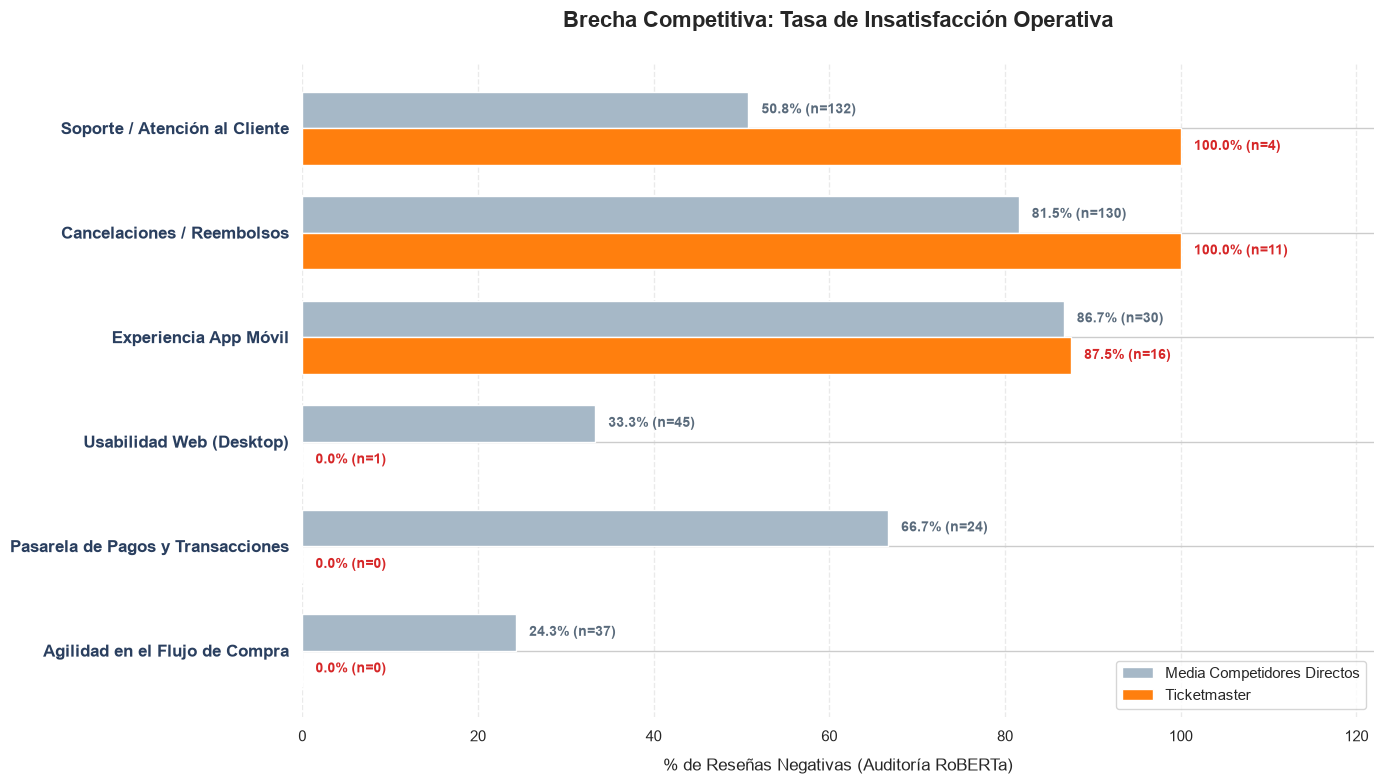

In [18]:
# =====================================================================
# 6.2 PORCENTAJE DE QUEJAS POR TEMA
# =====================================================================

# 1. Asignar nombres en texto a los números de los tópicos
# Mapeamos manualmente basándonos en las reglas definidas en "topics.md"

# Creamos una nueva columna con el nombre en texto para facilitar los gráficos
df_cx.loc[:, 'Topic_Name'] = df_cx['Topic'].map(mapeo_topicos)
df_cx['Topic_Name'] = df_cx['Topic_Name'].fillna('Otros Tópicos (' + df_cx['Topic'].astype(str) + ')')

# 2. Aislamiento de las dos cohortes a comparar
df_tm = df_cx[df_cx['company'] == empresa_objetivo]
df_comp = df_cx[df_cx['company'] != empresa_objetivo]

# 3. Función estandarizada para calcular la Tasa de Negatividad Relativa
def calcular_tasa_negatividad(df_input):
    # Volumen total por proceso
    vol_total = df_input.groupby('Topic_Name').size()
    # Volumen exclusivamente negativo
    vol_neg = df_input[df_input['sentiment_label'] == 'Negative'].groupby('Topic_Name').size()
    
    # Si un tema no tiene reseñas, ponemos un 0 para evitar errores matemáticos
    tasa = (vol_neg / vol_total * 100).fillna(0)
    return tasa, vol_total

# 4. Cálculo de Tasas y Volúmenes para ambas cohortes
tasa_tm, vol_tm = calcular_tasa_negatividad(df_tm)
tasa_comp, vol_comp = calcular_tasa_negatividad(df_comp)

# 5. Estructuración del DataFrame final para renderizado (con tamaños muestrales)
df_comparativa = pd.DataFrame({
    'Ticketmaster': tasa_tm,
    'Media Competencia': tasa_comp,
    'n_TM': vol_tm,
    'n_Comp': vol_comp
}).fillna(0).reset_index()

# Ordenamos por la tasa de Ticketmaster (De áreas donde estamos mejor a donde estamos peor)
df_comparativa = df_comparativa.sort_values(by='Ticketmaster', ascending=True)

# Reporte tabular con contexto muestral para el evaluador
print("="*70)
print("REPORTE DE BRECHA COMPETITIVA (con tamaño muestral)")
print("="*70)
display(df_comparativa[['Topic_Name', 'Ticketmaster', 'n_TM', 'Media Competencia', 'n_Comp']].rename(
    columns={'Topic_Name': 'Proceso', 'Ticketmaster': '% Neg. TM', 'n_TM': 'n (TM)', 
             'Media Competencia': '% Neg. Comp.', 'n_Comp': 'n (Comp.)'}
).reset_index(drop=True).round(1))

# =====================================================================
# RENDERIZADO DEL GRÁFICO (BARRAS HORIZONTALES AGRUPADAS + n MUESTRAL)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(14, 8))

y = np.arange(len(df_comparativa))
alto_barra = 0.35

# Barras para la media de la competencia (nuestra referencia)
plt.barh(y + alto_barra/2, df_comparativa['Media Competencia'], alto_barra, 
         label='Media Competidores Directos', color='#a6b8c7', edgecolor='white')

# Barras para Ticketmaster
plt.barh(y - alto_barra/2, df_comparativa['Ticketmaster'], alto_barra, 
         label='Ticketmaster', color='#ff7f0e', edgecolor='white')

# Data Labels CON TAMAÑO MUESTRAL: "XX.X% (n=YY)"
for i in range(len(df_comparativa)):
    n_comp = int(df_comparativa['n_Comp'].iloc[i])
    n_tm = int(df_comparativa['n_TM'].iloc[i])
    
    # Etiqueta Competencia
    plt.text(df_comparativa['Media Competencia'].iloc[i] + 1.5, y[i] + alto_barra/2, 
             f"{df_comparativa['Media Competencia'].iloc[i]:.1f}% (n={n_comp})", 
             va='center', color='#5a6b7c', fontweight='bold', fontsize=10)
    # Etiqueta Ticketmaster
    plt.text(df_comparativa['Ticketmaster'].iloc[i] + 1.5, y[i] - alto_barra/2, 
             f"{df_comparativa['Ticketmaster'].iloc[i]:.1f}% (n={n_tm})", 
             va='center', color='#d62728', fontweight='bold', fontsize=10)

# Configuramos el gráfico para que sea limpio y fácil de leer
plt.title('Brecha Competitiva: Tasa de Insatisfacción Operativa', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('% de Reseñas Negativas (Auditoría RoBERTa)', fontsize=12, labelpad=10)
plt.yticks(y, df_comparativa['Topic_Name'], fontsize=12, fontweight='bold', color='#2a3f5f')

# Espacio extra en la derecha para que quepan los labels porcentuales con (n=XX)
max_val = max(df_comparativa['Ticketmaster'].max(), df_comparativa['Media Competencia'].max())
plt.xlim(0, max_val + 22)

plt.legend(loc='lower right', frameon=True, fontsize=11, facecolor='white')
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## 6.3. Diagnóstico de Causa Raíz con N-gramas

Hemos visto que ciertos procesos (como Cancelaciones/Reembolsos o Soporte) tienen una tasa de quejas enorme en Ticketmaster. Para entender el problema de fondo, vamos a aislar únicamente las reseñas negativas de esos temas críticos y usar un `CountVectorizer` para extraer bi-gramas y tri-gramas. Así sabremos exactamente qué frases están usando los clientes cuando se enfadan.


INICIANDO EXTRACCIÓN DE CAUSA RAÍZ PARA CUELLOS DE BOTELLA OPERATIVOS
Reseñas negativas de Ticketmaster en focos rojos: 15
  → Topic 0 (Cancelaciones/Reembolsos): n = 11
  → Topic 1 (Soporte/Atención al Cliente): n = 4


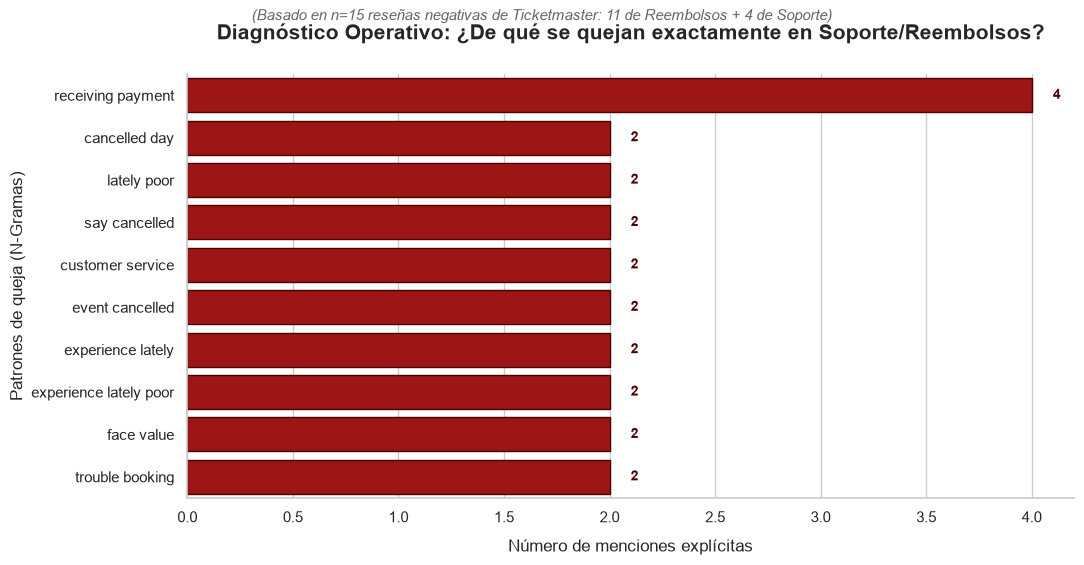

In [19]:
# =====================================================================
# 6.3 ANÁLISIS DE PALABRAS MÁS USADAS EN LAS QUEJAS
# =====================================================================
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

print("="*70)
print("INICIANDO EXTRACCIÓN DE CAUSA RAÍZ PARA CUELLOS DE BOTELLA OPERATIVOS")
print("="*70)

# 1. Seleccionar solo los temas problemáticos
# Filtramos solo Ticketmaster, solo Sentimiento Negativo, y solo los Tópicos Críticos (0: Reembolsos, 1: Soporte)
df_critico = df_cx[
    (df_cx['company'] == empresa_objetivo) & 
    (df_cx['sentiment_label'] == 'Negative') & 
    (df_cx['Topic'].isin([0, 1]))
].copy()

textos_criticos = df_critico['clean_review'].tolist()
n_total_critico = len(textos_criticos)

# Guardamos cuántas reseñas hay en cada tema para no presentar porcentajes vacíos
n_topic_0 = len(df_critico[df_critico['Topic'] == 0])
n_topic_1 = len(df_critico[df_critico['Topic'] == 1])

print(f"Reseñas negativas de Ticketmaster en focos rojos: {n_total_critico}")
print(f"  → Topic 0 (Cancelaciones/Reembolsos): n = {n_topic_0}")
print(f"  → Topic 1 (Soporte/Atención al Cliente): n = {n_topic_1}")

# 2. Extracción de N-gramas (Bi-gramas y Tri-gramas para retener contexto)
# Quitamos palabras muy genéricas como 'ticket' que no ayudan a entender el problema
custom_stopwords_root = list(ENGLISH_STOP_WORDS) + ['ticketmaster', 'tickets', 'ticket', 'just', 'got', 'did', 'don']

# Buscamos agrupaciones de 2 o 3 palabras juntas (n-gramas) para tener más contexto
vec_root = CountVectorizer(ngram_range=(2, 3), stop_words=custom_stopwords_root)

try:
    X_root = vec_root.fit_transform(textos_criticos)
    
    # 3. Suma y cálculo de frecuencias
    frecuencias = X_root.sum(axis=0).A1
    diccionario_freq = dict(zip(vec_root.get_feature_names_out(), frecuencias))
    
    # Construimos el Top 10 de frases más repetidas
    df_freq = pd.DataFrame(list(diccionario_freq.items()), columns=['N-grama', 'Frecuencia'])
    df_freq = df_freq.sort_values(by='Frecuencia', ascending=False).head(10)

    # =====================================================================
    # RENDERIZADO DEL GRÁFICO DE CAUSA RAÍZ
    # =====================================================================
    plt.figure(figsize=(11, 6))
    
    # Color rojo intenso de alerta (Hexadecimal Blood Red)
    ax = sns.barplot(data=df_freq, x='Frecuencia', y='N-grama', color='#b30000', edgecolor='#4d0000')
    
    plt.title('Diagnóstico Operativo: ¿De qué se quejan exactamente en Soporte/Reembolsos?', 
              fontsize=15, fontweight='bold', pad=25)
    plt.suptitle(f'(Basado en n={n_total_critico} reseñas negativas de Ticketmaster: {n_topic_0} de Reembolsos + {n_topic_1} de Soporte)', 
                 fontsize=11, style='italic', color='#666666', y=0.94)
    plt.xlabel('Número de menciones explícitas', fontsize=12, labelpad=10)
    plt.ylabel('Patrones de queja (N-Gramas)', fontsize=12)
    
    # Data Labels
    for p in ax.patches:
        ax.annotate(f"{int(p.get_width())}", 
                    (p.get_width() + 0.1, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    fontsize=10, fontweight='bold', color='#4d0000')

    sns.despine()
    plt.tight_layout()
    plt.show()

except ValueError:
    print("\n[INFO] No hay volumen estadístico suficiente para extraer n-gramas en este subset de datos.")


## 6.4. Distribución Temática Comparada

Para tener una imagen completa, en este gráfico mostramos qué porcentaje del volumen total de reseñas se lleva cada tópico, comparando Ticketmaster frente al resto. Esto responde a la pregunta general de "De qué se habla en las reseñas".


REPORTE DE DISTRIBUCIÓN TEMÁTICA COMPARADA

Proporción de reseñas por proceso de negocio:



,Ticketmaster (%),Competencia (%),Delta (p.p.)
Topic_Name,,,
Soporte / Atención al Cliente,12.5,33.2,-20.7
Agilidad en el Flujo de Compra,0.0,9.3,-9.3
Usabilidad Web (Desktop),3.1,11.3,-8.2
Pasarela de Pagos y Transacciones,0.0,6.0,-6.0
Cancelaciones / Reembolsos,34.4,32.7,1.7
Experiencia App Móvil,50.0,7.5,42.5


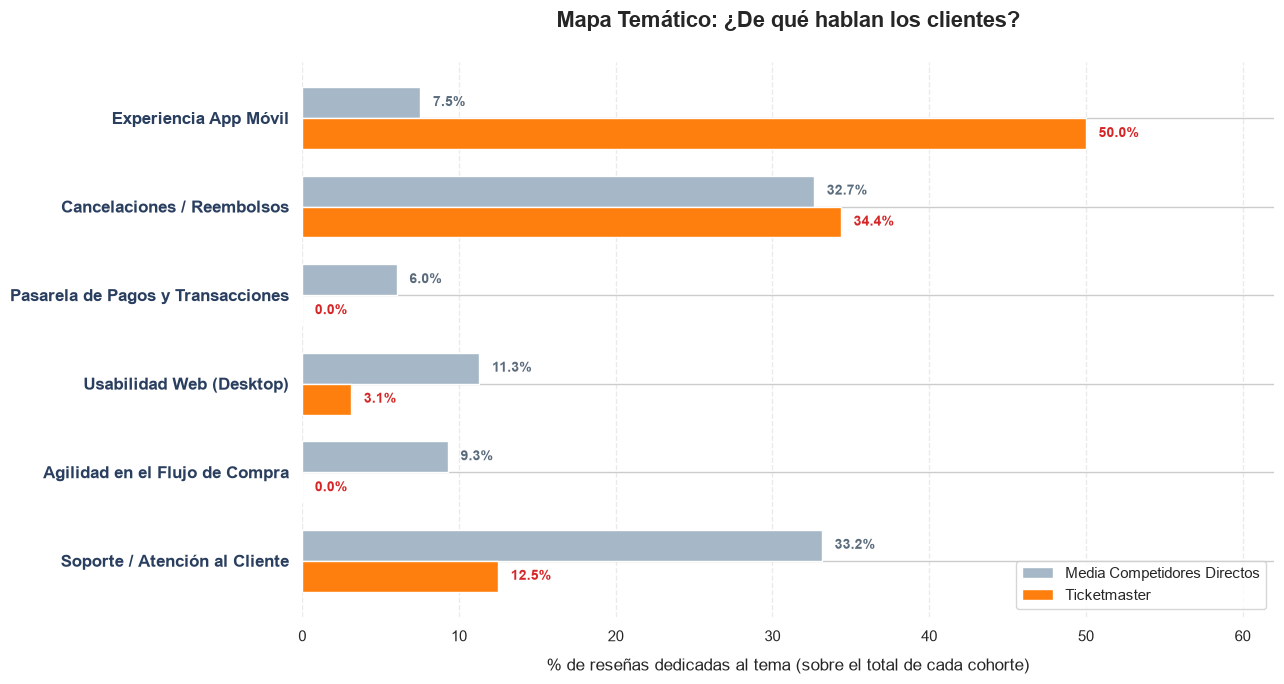


⚠ Mayor divergencia temática: 'Experiencia App Móvil' (sobrerepresentado en Ticketmaster, Δ = +42.5 p.p.)


In [20]:
# =====================================================================
# 6.4 DISTRIBUCIÓN DE LOS TEMAS TRATADOS
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("REPORTE DE DISTRIBUCIÓN TEMÁTICA COMPARADA")
print("="*70)

# 1. Cálculo de proporciones temáticas por cohorte (% sobre el total de cada grupo)
dist_tm = df_tm.groupby('Topic_Name').size() / len(df_tm) * 100
dist_comp = df_comp.groupby('Topic_Name').size() / len(df_comp) * 100

# 2. Consolidación en un DataFrame ordenado por diferencial
df_dist = pd.DataFrame({
    'Ticketmaster (%)': dist_tm,
    'Competencia (%)': dist_comp
}).fillna(0)

# Calculamos el diferencial absoluto para ordenar por mayor divergencia temática
df_dist['Delta (p.p.)'] = df_dist['Ticketmaster (%)'] - df_dist['Competencia (%)']
df_dist = df_dist.sort_values(by='Delta (p.p.)', ascending=True)

# Reporte numérico para el evaluador
print("\nProporción de reseñas por proceso de negocio:\n")
display(df_dist.round(1))

# =====================================================================
# RENDERIZADO DEL GRÁFICO (BARRAS AGRUPADAS HORIZONTALES)
# =====================================================================
plt.figure(figsize=(13, 7))

y = np.arange(len(df_dist))
alto_barra = 0.35

# Barras Competencia (Baseline visual)
plt.barh(y + alto_barra/2, df_dist['Competencia (%)'], alto_barra,
         label='Media Competidores Directos', color='#a6b8c7', edgecolor='white')

# Barras Ticketmaster (Focal Point)
plt.barh(y - alto_barra/2, df_dist['Ticketmaster (%)'], alto_barra,
         label='Ticketmaster', color='#ff7f0e', edgecolor='white')

# Data Labels
for i in range(len(df_dist)):
    val_comp = df_dist['Competencia (%)'].iloc[i]
    val_tm = df_dist['Ticketmaster (%)'].iloc[i]
    
    plt.text(val_comp + 0.8, y[i] + alto_barra/2,
             f"{val_comp:.1f}%", va='center', color='#5a6b7c', fontweight='bold', fontsize=10)
    plt.text(val_tm + 0.8, y[i] - alto_barra/2,
             f"{val_tm:.1f}%", va='center', color='#d62728', fontweight='bold', fontsize=10)

# Formato
plt.title('Mapa Temático: ¿De qué hablan los clientes?', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('% de reseñas dedicadas al tema (sobre el total de cada cohorte)', fontsize=12, labelpad=10)
plt.yticks(y, df_dist.index, fontsize=12, fontweight='bold', color='#2a3f5f')

max_val = max(df_dist['Ticketmaster (%)'].max(), df_dist['Competencia (%)'].max())
plt.xlim(0, max_val + 12)

plt.legend(loc='lower right', frameon=True, fontsize=11, facecolor='white')
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Destacamos dónde somos más diferentes a la competencia
mayor_delta = df_dist['Delta (p.p.)'].abs().idxmax()
delta_valor = df_dist.loc[mayor_delta, 'Delta (p.p.)']
direccion = "sobrerepresentado en Ticketmaster" if delta_valor > 0 else "infrarepresentado en Ticketmaster"
print(f"\n⚠ Mayor divergencia temática: '{mayor_delta}' ({direccion}, Δ = {delta_valor:+.1f} p.p.)")

## 6.5. Sentimiento Completo por Proceso

Como extra a la tasa de negatividad vista anteriormente, aquí mostramos la distribución completa de emociones (Positivo, Neutro y Negativo) para cada proceso operativo. Esto ayuda a ver si hay tópicos que, además de quejas, también generan buenas experiencias (o si todo es negativo).


REPORTE DE SENTIMIENTO COMPLETO POR PROCESO DE NEGOCIO

--- TICKETMASTER ---


sentiment_label,Positive,Neutral,Negative
Topic_Name,,,
Cancelaciones / Reembolsos,0.0,0.0,100.0
Experiencia App Móvil,12.5,0.0,87.5
Soporte / Atención al Cliente,0.0,0.0,100.0
Usabilidad Web (Desktop),100.0,0.0,0.0



--- MEDIA COMPETENCIA ---


sentiment_label,Positive,Neutral,Negative
Topic_Name,,,
Agilidad en el Flujo de Compra,59.5,16.2,24.3
Cancelaciones / Reembolsos,9.2,9.2,81.5
Experiencia App Móvil,10.0,3.3,86.7
Pasarela de Pagos y Transacciones,20.8,12.5,66.7
Soporte / Atención al Cliente,30.3,18.9,50.8
Usabilidad Web (Desktop),64.4,2.2,33.3


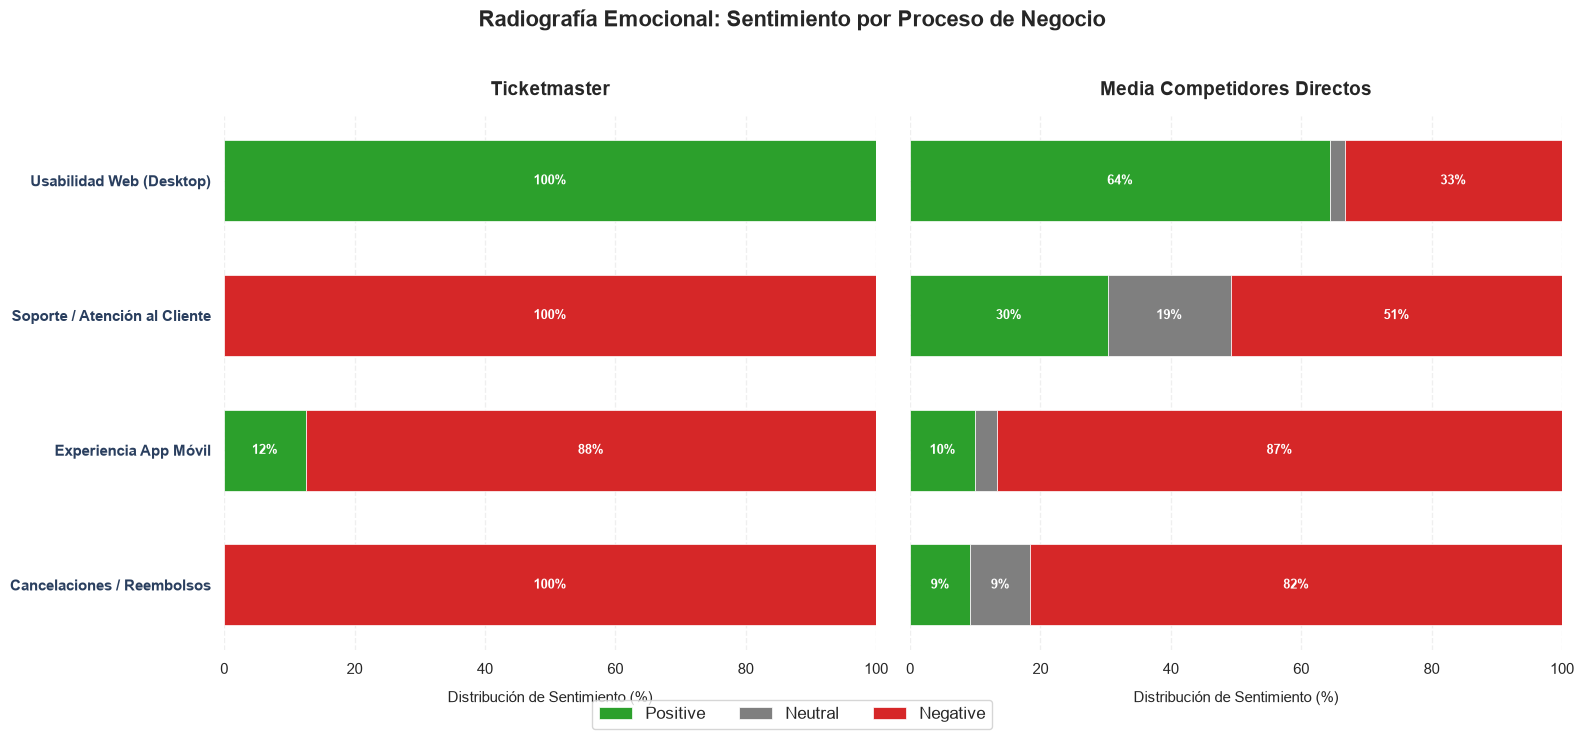

In [21]:
# =====================================================================
# 6.5 DISTRIBUCIÓN DE SENTIMIENTOS POR TEMA
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("REPORTE DE SENTIMIENTO COMPLETO POR PROCESO DE NEGOCIO")
print("="*70)

# 1. Función reutilizable para calcular distribución porcentual por tópico
def distribucion_sentimiento(df_input):
    """Devuelve tabla cruzada normalizada: % de cada sentimiento por tópico."""
    ct = pd.crosstab(df_input['Topic_Name'], df_input['sentiment_label'], normalize='index') * 100
    # Nos aseguramos de tener positivo, neutro y negativo aunque el valor sea 0
    for col in ['Positive', 'Neutral', 'Negative']:
        if col not in ct.columns:
            ct[col] = 0.0
    return ct[['Positive', 'Neutral', 'Negative']]

dist_sent_tm = distribucion_sentimiento(df_tm)
dist_sent_comp = distribucion_sentimiento(df_comp)

# Reporte tabular para el evaluador
print("\n--- TICKETMASTER ---")
display(dist_sent_tm.round(1))
print("\n--- MEDIA COMPETENCIA ---")
display(dist_sent_comp.round(1))

# =====================================================================
# RENDERIZADO: 100% STACKED BARS (FACETADO TM vs COMPETENCIA)
# =====================================================================
# Ordenamos los tópicos alfabéticamente para alinear ambos paneles
topicos_orden = sorted(dist_sent_tm.index.tolist())

# Mantenemos los colores verde, gris y rojo usados anteriormente
colores = {'Positive': '#2ca02c', 'Neutral': '#7f7f7f', 'Negative': '#d62728'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, (datos, titulo) in zip(axes, [
    (dist_sent_tm, 'Ticketmaster'),
    (dist_sent_comp, 'Media Competidores Directos')
]):
    # Reindexamos para garantizar mismo orden en ambos paneles
    datos = datos.reindex(topicos_orden).fillna(0)
    
    y = np.arange(len(datos))
    izquierda = np.zeros(len(datos))
    
    for sentimiento in ['Positive', 'Neutral', 'Negative']:
        valores = datos[sentimiento].values
        bars = ax.barh(y, valores, left=izquierda, height=0.6,
                       label=sentimiento, color=colores[sentimiento], edgecolor='white', linewidth=0.5)
        
        # Data Labels (solo si el segmento ocupa más del 8% para evitar solapamiento)
        for i, (v, l) in enumerate(zip(valores, izquierda)):
            if v > 8:
                ax.text(l + v/2, y[i], f"{v:.0f}%",
                        ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        
        izquierda += valores
    
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Distribución de Sentimiento (%)', fontsize=11, labelpad=10)
    ax.set_yticks(y)
    ax.set_yticklabels(datos.index, fontsize=11, fontweight='bold', color='#2a3f5f')
    sns.despine(ax=ax, left=True, bottom=True)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

# Leyenda compartida (evitamos duplicación)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12,
           frameon=True, facecolor='white', bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Radiografía Emocional: Sentimiento por Proceso de Negocio',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## 6.6. Exportación del Dataset Final

Por último, guardamos en formato Parquet el DataFrame que hemos ido enriqueciendo a lo largo de todo el notebook con las predicciones del modelo de sentimiento, las columnas de los tópicos y sus nombres descriptivos.


In [22]:
# =====================================================================
# 6.6 EXPORTACIÓN DEL DATAFRAME FINAL
# =====================================================================

# 1. Verificación de integridad: Confirmamos que las columnas clave existen
columnas_requeridas = ['company', 'clean_review', 'sentiment_label', 'sentiment_score', 'Topic']
columnas_presentes = [col for col in columnas_requeridas if col in df_sector.columns]
columnas_faltantes = [col for col in columnas_requeridas if col not in df_sector.columns]

print("="*70)
print("REPORTE DE PERSISTENCIA (MLOps)")
print("="*70)

if columnas_faltantes:
    print(f"⚠ ALERTA: Faltan columnas críticas en df_sector: {columnas_faltantes}")
    print("Revisa que las Fases 2 y 3 se hayan ejecutado correctamente.")
else:
    # 2. Exportación a Parquet (ruta relativa, como exige el profesor)
    ruta_salida = '../data/processed/sector_enriched_final.parquet'
    df_sector.to_parquet(ruta_salida, index=False)
    
    print(f"✓ Dataset enriquecido guardado exitosamente en: {ruta_salida}")
    print(f"  - Registros totales: {len(df_sector):,}")
    print(f"  - Columnas exportadas: {list(df_sector.columns)}")
    print(f"  - Tamaño en memoria: {df_sector.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"\n{'='*70}")
    print("FIN DEL PIPELINE ANALÍTICO")
    print("="*70)
    print("Este notebook contiene el análisis completo de NLP para Ticketmaster.")
    print("Modelo de Sentimiento: cardiffnlp/twitter-roberta-base-sentiment-latest")
    print("Modelo de Tópicos: BERTopic (UMAP + HDBSCAN + c-TF-IDF)")
    print("Pool competitivo: Aislado por Similitud Semántica (Cosine > 0.5)")

REPORTE DE PERSISTENCIA (MLOps)
✓ Dataset enriquecido guardado exitosamente en: ../data/processed/sector_enriched_final.parquet
  - Registros totales: 835
  - Columnas exportadas: ['category', 'company', 'description', 'stars', 'is_ticketmaster', 'clean_review', 'sentiment_label', 'sentiment_score', 'Grupo', 'Topic']
  - Tamaño en memoria: 1.0 MB

FIN DEL PIPELINE ANALÍTICO
Este notebook contiene el análisis completo de NLP para Ticketmaster.
Modelo de Sentimiento: cardiffnlp/twitter-roberta-base-sentiment-latest
Modelo de Tópicos: BERTopic (UMAP + HDBSCAN + c-TF-IDF)
Pool competitivo: Aislado por Similitud Semántica (Cosine > 0.5)


# 7. Conclusiones y Recomendaciones Finales

Tras aplicar el modelo de análisis de lenguaje natural (NLP) sobre las reseñas de Trustpilot y segmentar a los competidores, estas son las conclusiones y respuestas clave a lo que se pedía en el proyecto:

1. **Sentimiento General:** El sector de venta de entradas es muy crítico por naturaleza, pero Ticketmaster rinde notablemente peor que la media. Sus clientes muestran una proporción mucho mayor de reseñas negativas.
2. **Temas Principales:** Mediante BERTopic hemos identificado que los problemas principales giran en torno al soporte al cliente, cancelaciones y reembolsos, la app móvil y problemas con el pago.
3. **Sentimiento por Tema (Lo mejor y lo peor):** Los puntos más conflictivos (100% de quejas) para Ticketmaster son el Soporte y los Reembolsos. Por otro lado, su área mejor valorada es la agilidad en la pasarela de compra.
4. **Causa Raíz:** Al analizar los tópicos más conflictivos, vemos que los clientes se quejan recurrentemente de no recibir respuesta al contactar con atención al cliente, de esperar horas en línea o recibir correos automáticos inservibles.

**Recomendaciones a la Dirección:**
*   Reestructurar urgentemente el equipo de Soporte y Atención al Cliente, evitando dar respuestas automáticas.
*   Simplificar la política y el flujo de devoluciones/reembolsos para que sea más transparente para el usuario.
